# Fintechs y AGFs Chile · análisis macro del perímetro regulatorio (v2 deep)

> **Tesis del notebook**: el sistema financiero chileno opera bajo **dos regímenes
> regulatorios paralelos** que el SDK Cerberus permite cruzar de extremo a extremo:
>
> 1. **CMF clásico** — bancos, seguros, AGFs, emisores. Inscripción obligatoria
>    desde 1980+, Ley 18.045 (Mercado de Valores), 18.046 (Sociedades Anónimas),
>    20.712 (LUF). Canal: **registro de entidades CMF**. Régimen sancionatorio
>    duro y público.
> 2. **Ley Fintec (21.521, Feb-2024)** — fintechs que prestan servicios
>    específicos: asesoría de inversión, asesoría crediticia, custodia de
>    instrumentos, intermediación, ruteo de órdenes, plataformas de
>    financiamiento colectivo, sistemas alternativos de transacción. Canal:
>    **Registro de Prestadores de Servicios Financieros (RPSF)**. Régimen recién
>    naciente.
>
> Las **AGFs vigentes** son el bullseye del régimen 1; las **fintechs pure-play**
> (Mercado Pago, MACH, Khipu, Cumplo, Buda, Xepelin, Toku…) viven mayoritariamente
> **fuera de ambos**. Las **fintechs de servicio regulado** (Betterplan→asesoría;
> Koywe→custodia) viven en RPSF pero **no en el universo CMF clásico**.
>
> Este notebook **mide ese perímetro entidad por entidad**: 23 entidades en CMF +
> 17 candidates fuera, cruzando KYB · directorios · LEI · sanciones · regulaciones ·
> hechos esenciales · cross-reference internacional · RPSF · búsqueda semántica ·
> telón macro · 12 dimensiones de cobertura comparada.

---

### Portafolio CMF analizado (23 entidades · RUTs canónicos validados live)

#### AGFs vigentes (15)

| # | Razón social | RUT | Sub-segmento | Grupo |
|---|---|---|---|---|
| 1 | BANCHILE AGF | 96.767.630-6 | bank-affiliated | Banco de Chile |
| 2 | BTG PACTUAL CHILE AGF | 96.966.250-7 | boutique | BTG Pactual |
| 3 | BCI ASSET MANAGEMENT AGF | 96.530.900-4 | bank-affiliated | BCI |
| 4 | BICE INVERSIONES AGF | 96.514.410-2 | bank-affiliated | Grupo Bice |
| 5 | VINCI COMPASS AGF | 96.804.330-7 | boutique | Vinci Compass |
| 6 | PRINCIPAL ASSET MANAGEMENT AGF | 91.999.000-7 | global-affiliated | Principal Financial |
| 7 | FINTUAL AGF | 76.810.627-4 | fintech-disrupted | Fintual |
| 8 | MONEDA S.A. AGF | 96.684.990-8 | boutique | Patria Investments |
| 9 | FALCOM AGF | 76.507.811-3 | boutique | Falcom |
| 10 | SANTANDER ASSET MANAGEMENT AGF | 96.667.040-1 | bank-affiliated | Santander |
| 11 | LARRAINVIAL ASSET MANAGEMENT AGF | 96.955.500-K | boutique | LarrainVial |
| 12 | ITAÚ AGF | 96.980.650-9 | bank-affiliated | Itaú |
| 13 | AGF SECURITY S.A. | 96.639.280-0 | bank-affiliated | Grupo Security |
| 14 | TOESCA S.A. AGF | 96.576.660-K | boutique | Toesca |
| 15 | MBI AGF | 99.543.100-9 | boutique | MBI |

#### AGFs no vigentes (5) · *arqueología regulatoria*

| # | Razón social | RUT | Estado |
|---|---|---|---|
| 16 | BCI AGF (legacy) | 76.708.560-5 | no_vigente |
| 17 | PENTA AGF | 99.558.780-7 | no_vigente |
| 18 | ZURICH AGF | 99.580.930-3 | no_vigente |
| 19 | SCOTIA AZUL AGF | 96.815.680-2 | no_vigente |
| 20 | SARTOR AGF | 76.576.607-9 | no_vigente |

#### Fintech / non-bank consumer finance EN universo CMF (3)

| # | Razón social | RUT | Sub-rubro |
|---|---|---|---|
| 21 | TENPO BANK CHILE | 76.632.789-3 | wallet → banco digital |
| 22 | FINTUAL CROWD SPA | 76.086.428-5 | crowdfunding |
| 23 | TANNER SERVICIOS FINANCIEROS S.A. | 96.667.560-8 | factoring · leasing |

### Fintechs zona gris · candidatos a RPSF (17)

Mercado Pago · MACH · Khipu · **Cumplo** · Buda.com · **Xepelin** · Toku · Kushki ·
Fintoc · **Global66** · Racional · Compara Online · **Destácame** · **Galgo** ·
**Betterplan Advisors** · **Koywe** · Credicorp Capital — analizadas vía
`resolve.resolve` y `rpsf.by_entity` para descubrir si están inscritas
bajo Ley Fintec (sección §29).

### Endpoints exprimidos

| Endpoint | Calls | Para qué |
|---|---:|---|
| `kyb.get(include=…)` | 23 | Perfil + directores + LEI + hechos |
| `entities.by_rut` + `ownership` + `sanctions` | 69 | LEI canónico + grafo + sanciones |
| `sanctions.cross_reference` | ~30 | Threshold sweep + listas intl |
| `resolve.resolve` | 17 | Gap analysis fintechs |
| `rpsf.iter_all` + `rpsf.by_entity` | 25+ | Inventario Ley Fintec |
| `search.search` | 8 | Semántica fintech/AGF |
| `indicadores.history` | 4 | Macro 12m |

**Total**: ~180 llamadas live · concurrencia limitada · 0 retries esperados.

---

🔱 **Cerberus SDK · Fintechs y AGFs Chile · v2-deep** · 2026-05-04

## 1 · Setup · imports, portafolio y helpers

In [1]:
from __future__ import annotations

import asyncio
import logging
import os
import re
from collections import Counter
from datetime import date, timedelta

import nest_asyncio

nest_asyncio.apply()

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

assert os.getenv("CERBERUS_API_KEY"), (
    "Set CERBERUS_API_KEY before running this notebook (e.g. `export CERBERUS_API_KEY=ck_live_…`)."
)

logging.getLogger("cerberus_compliance").setLevel(logging.ERROR)
plt.rcParams.update(
    {
        "figure.dpi": 100,
        "axes.titlesize": 11,
        "axes.titleweight": "bold",
        "axes.spines.right": False,
        "axes.spines.top": False,
        "font.size": 9,
    }
)

import cerberus_compliance
from cerberus_compliance import AsyncCerberusClient, CerberusClient

print(f"SDK version: {cerberus_compliance.__version__}")

SDK version: 0.6.0


In [2]:
# (rut, hint, sector, sub_segment, parent_group)
# Todos los RUTs validados live contra https://compliance.cerberus.cl —
# canonicalizados vía resolve.resolve cuando el RUT popularmente atribuido
# diferia del registrado en CMF.
PORTFOLIO: list[tuple[str, str, str, str, str | None]] = [
    # ── AGFs vigentes (15) — núcleo del análisis ──────────────────────────
    ("96767630-6", "Banchile AGF", "agf_vigente", "bank-affiliated", "Banco de Chile"),
    ("96966250-7", "BTG Pactual AGF", "agf_vigente", "boutique", "BTG Pactual"),
    ("96530900-4", "BCI AssetMgmt", "agf_vigente", "bank-affiliated", "BCI"),
    ("96514410-2", "Bice AGF", "agf_vigente", "bank-affiliated", "Grupo Bice"),
    ("96804330-7", "Vinci Compass", "agf_vigente", "boutique", "Vinci Compass"),
    ("91999000-7", "Principal AM", "agf_vigente", "global-affiliated", "Principal Financial"),
    ("76810627-4", "Fintual AGF", "agf_vigente", "fintech-disrupted", "Fintual"),
    ("96684990-8", "Moneda AGF", "agf_vigente", "boutique", "Patria Investments"),
    ("76507811-3", "Falcom AGF", "agf_vigente", "boutique", "Falcom"),
    ("96667040-1", "Santander AGF", "agf_vigente", "bank-affiliated", "Santander"),
    ("96955500-K", "LarrainVial AGF", "agf_vigente", "boutique", "LarrainVial"),
    ("96980650-9", "Itaú AGF", "agf_vigente", "bank-affiliated", "Itaú"),
    ("96639280-0", "Security AGF", "agf_vigente", "bank-affiliated", "Grupo Security"),
    ("96576660-K", "Toesca AGF", "agf_vigente", "boutique", "Toesca"),
    ("99543100-9", "MBI AGF", "agf_vigente", "boutique", "MBI"),
    # ── AGFs no_vigentes (5) — regulatory archaeology ─────────────────────
    ("76708560-5", "BCI AGF (legacy)", "agf_legacy", "bank-affiliated", "BCI"),
    ("99558780-7", "Penta AGF", "agf_legacy", "boutique", "Penta"),
    ("99580930-3", "Zurich AGF", "agf_legacy", "global-affiliated", "Zurich"),
    ("96815680-2", "Scotia Azul AGF", "agf_legacy", "bank-affiliated", "Scotiabank"),
    ("76576607-9", "Sartor AGF", "agf_legacy", "boutique", "Sartor"),
    # ── Fintech / non-bank consumer finance EN el universo CMF (3) ────────
    ("76632789-3", "Tenpo Bank", "fintech_in", "wallet→bank", "Krealo / Credicorp"),
    ("76086428-5", "Fintual Crowd", "fintech_in", "crowdfunding", "Fintual"),
    ("96667560-8", "Tanner", "fintech_in", "factoring·leasing", "Tanner"),
]

# Fintechs zona gris (RPSF candidates / fuera CMF clásico) — gap analysis §29
FINTECHS_OUT: list[tuple[str, str]] = [
    ("MERCADO PAGO CHILE", "wallet · pagos"),
    ("MACH (BCI Pagos)", "wallet"),
    ("KHIPU", "pagos · botón"),
    ("CUMPLO CHILE SPA", "p2p lending · factoring"),
    ("BUDA.COM", "exchange crypto"),
    ("XEPELIN SPA", "factoring digital"),
    ("TOKU PAGOS", "pagos recurrentes"),
    ("KUSHKI CHILE", "pagos · gateway"),
    ("FINTOC CHILE", "open banking"),
    ("GLOBAL66 SPA", "remesas · multimoneda"),
    ("RACIONAL SPA", "robo-advisor"),
    ("COMPARA ONLINE", "comparador"),
    ("DESTÁCAME SPA", "credit scoring"),
    ("GALGO CHILE", "financiamiento moto · auto"),
    ("BETTERPLAN ADVISORS SPA", "asesoría · planificación"),
    ("KOYWE SPA", "intermediación · custodia"),
    ("CREDICORP CAPITAL CHILE", "asset management"),
]

SECTOR_COLORS = {
    "agf_vigente": "#2ca02c",  # verde
    "agf_legacy": "#999999",  # gris
    "fintech_in": "#1f77b4",  # azul
}

SECTOR_LABEL = {
    "agf_vigente": "AGF vigente (CMF)",
    "agf_legacy": "AGF no_vigente (legacy)",
    "fintech_in": "Fintech en CMF",
}

SUB_SEGMENT_COLORS = {
    "bank-affiliated": "#1f77b4",
    "boutique": "#9467bd",
    "global-affiliated": "#8c564b",
    "fintech-disrupted": "#e377c2",
    "wallet→bank": "#17becf",
    "crowdfunding": "#bcbd22",
    "factoring·leasing": "#7f7f7f",
}

print(f"Portafolio CMF: {len(PORTFOLIO)} entidades  ·  Fintechs zona gris: {len(FINTECHS_OUT)}")
print(f"  AGFs vigentes:    {sum(1 for r in PORTFOLIO if r[2] == 'agf_vigente')}")
print(f"  AGFs no_vigentes: {sum(1 for r in PORTFOLIO if r[2] == 'agf_legacy')}")
print(f"  Fintech-in:       {sum(1 for r in PORTFOLIO if r[2] == 'fintech_in')}")

Portafolio CMF: 23 entidades  ·  Fintechs zona gris: 17
  AGFs vigentes:    15
  AGFs no_vigentes: 5
  Fintech-in:       3


In [3]:
async def gather_throttled(coro_factory, items, *, concurrency: int = 5):
    """Run coro_factory(client, item) over items with bounded concurrency."""
    sem = asyncio.Semaphore(concurrency)

    async def _wrapped(client, item):
        async with sem:
            return await coro_factory(client, item)

    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(_wrapped(c, item) for item in items))


def color_for(entity_hint: str, df_or_dict, default: str = "#999") -> str:
    """Resolve sector color for entity_hint, accepting dict or DataFrame."""
    sec = (
        df_or_dict.get(entity_hint, "")
        if isinstance(df_or_dict, dict)
        else (
            df_or_dict.set_index("hint")["sector"].to_dict() if "hint" in df_or_dict.columns else {}
        ).get(entity_hint, "")
    )
    return SECTOR_COLORS.get(sec, default)


def style_axes(
    ax,
    title: str | None = None,
    xlabel: str | None = None,
    ylabel: str | None = None,
    grid: bool = True,
) -> None:
    if title:
        ax.set_title(title)
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    if grid:
        ax.grid(axis="x", alpha=0.25, linestyle="--")


def add_value_labels(ax, bars, fmt: str = "{:.0f}", offset: float = 0.02) -> None:
    """Annotate bar values just past the end of each bar."""
    if not len(bars):
        return
    xmax = max((b.get_width() for b in bars), default=1)
    pad = (xmax or 1) * offset
    for b in bars:
        v = b.get_width()
        if v == 0 or pd.isna(v):
            continue
        ax.text(v + pad, b.get_y() + b.get_height() / 2, fmt.format(v), va="center", fontsize=8)


print("helpers OK")

helpers OK


## 2 · Fetch KYB de las 23 entidades · perfil completo

`kyb.get(rut, include=[...])` trae el perfil consolidado: legal_name, status,
inscripción/cancelación, LEI, risk_score, directores actuales y hechos
esenciales recientes. Capturamos 404s explícitamente.

In [4]:
def _empty_profile(rut, hint, sector, sub, parent, *, err: str | None = None) -> dict:
    return {
        "rut": rut,
        "hint": hint,
        "sector": sector,
        "sub_segment": sub,
        "parent_group": parent,
        "legal_name": None,
        "fantasy_name": None,
        "kind": None,
        "status": None,
        "size_bucket": None,
        "inscription_date": None,
        "cancellation_date": None,
        "lei": None,
        "risk_score": None,
        "risk_factors": [],
        "n_directors": 0,
        "n_recent_events": 0,
        "sanctions_total": None,
        "sanctions_vigentes": None,
        "sanctions_historical": None,
        "_directors": [],
        "_events": [],
        "_kyb_err": err,
    }


async def fetch_kyb(c, item):
    rut, hint, sector, sub, parent = item
    try:
        p = await c.kyb.get(rut=rut, include=["directors", "lei", "hechos_esenciales"])
    except Exception as e:
        return _empty_profile(rut, hint, sector, sub, parent, err=str(e)[:160])
    sa = p.get("sanctions") or {}
    return {
        "rut": rut,
        "hint": hint,
        "sector": sector,
        "sub_segment": sub,
        "parent_group": parent,
        "legal_name": p.get("legal_name"),
        "fantasy_name": p.get("fantasy_name"),
        "kind": p.get("entity_kind"),
        "status": p.get("status"),
        "size_bucket": p.get("size_bucket"),
        "inscription_date": p.get("inscription_date"),
        "cancellation_date": p.get("cancellation_date"),
        "lei": p.get("lei"),
        "risk_score": p.get("risk_score"),
        "risk_factors": p.get("risk_factors", []),
        "n_directors": len(p.get("directors_current") or []),
        "n_recent_events": len(p.get("recent_material_events") or []),
        "sanctions_total": sa.get("total_count"),
        "sanctions_vigentes": sa.get("vigentes_count"),
        "sanctions_historical": sa.get("historical_count"),
        "_directors": p.get("directors_current") or [],
        "_events": p.get("recent_material_events") or [],
        "_kyb_err": None,
    }


profiles = asyncio.run(gather_throttled(fetch_kyb, PORTFOLIO, concurrency=5))

_missing = [p for p in profiles if p.get("_kyb_err")]
if _missing:
    print(f"⚠️  {len(_missing)}/{len(PORTFOLIO)} entidades no se pudieron resolver vía kyb:")
    for p in _missing:
        print(f"   {p['hint']:20s} {p['rut']:12s}  {p['_kyb_err']}")
else:
    print(f"✓ Las {len(PORTFOLIO)} entidades del portafolio respondieron OK al kyb.get")

df = pd.DataFrame(profiles)
df["inscription_date"] = pd.to_datetime(df["inscription_date"], errors="coerce")
df["cancellation_date"] = pd.to_datetime(df["cancellation_date"], errors="coerce")
df["age_years"] = ((pd.Timestamp.today() - df["inscription_date"]).dt.days / 365.25).round(1)
print()
print(f"Distribución sector:        {dict(df['sector'].value_counts())}")
print(f"Distribución sub_segment:   {dict(df['sub_segment'].value_counts())}")

✓ Las 23 entidades del portafolio respondieron OK al kyb.get

Distribución sector:        {'agf_vigente': np.int64(15), 'agf_legacy': np.int64(5), 'fintech_in': np.int64(3)}
Distribución sub_segment:   {'boutique': np.int64(9), 'bank-affiliated': np.int64(8), 'global-affiliated': np.int64(2), 'fintech-disrupted': np.int64(1), 'wallet→bank': np.int64(1), 'crowdfunding': np.int64(1), 'factoring·leasing': np.int64(1)}


### Snapshot tabular del portafolio

In [5]:
df[
    [
        "hint",
        "legal_name",
        "sector",
        "sub_segment",
        "parent_group",
        "status",
        "risk_score",
        "n_directors",
        "lei",
        "age_years",
    ]
]

,hint,legal_name,sector,sub_segment,parent_group,status,risk_score,n_directors,lei,age_years
0,Banchile AGF,BANCHILE ADMINISTRADORA GENERAL DE FONDOS S.A.,agf_vigente,bank-affiliated,Banco de Chile,vigente,0,0,549300PFI630K07QHI12,NaN
1,BTG Pactual AGF,BTG PACTUAL CHILE S.A. ADMINISTRADORA GENERAL ...,agf_vigente,boutique,BTG Pactual,vigente,0,0,549300ZVBGRGB6OL8759,NaN
2,BCI AssetMgmt,BCI ASSET MANAGEMENT ADMINISTRADORA GENERAL D...,agf_vigente,bank-affiliated,BCI,vigente,0,0,2549003PWNEB1P1TAL95,NaN
3,Bice AGF,BICE INVERSIONES ADMINISTRADORA GENERAL DE FON...,agf_vigente,bank-affiliated,Grupo Bice,vigente,0,0,2549007CE0XCD4HUKN58,NaN
4,Vinci Compass,VINCI COMPASS S.A. ADMINISTRADORA GENERAL DE F...,agf_vigente,boutique,Vinci Compass,vigente,0,0,254900O3DCTK2GPEA896,NaN
5,Principal AM,PRINCIPAL ASSET MANAGEMENT ADMINISTRADORA GENE...,agf_vigente,global-affiliated,Principal Financial,vigente,0,0,549300R9YHEPJA5WOV09,NaN
6,Fintual AGF,FINTUAL ADMINISTRADORA GENERAL DE FONDOS S.A.,agf_vigente,fintech-disrupted,Fintual,vigente,0,0,2549004RUEQB0XKNTI34,NaN
7,Moneda AGF,MONEDA S.A. ADMINISTRADORA GENERAL DE FONDOS,agf_vigente,boutique,Patria Investments,vigente,0,0,549300O3RIGG8W2NLH04,NaN
8,Falcom AGF,FALCOM ADMINISTRADORA GENERAL DE FONDOS S.A.,agf_vigente,boutique,Falcom,vigente,0,0,254900AT2YKV4Q01CM92,NaN
9,Santander AGF,SANTANDER ASSET MANAGEMENT S.A. ADMINISTRADORA...,agf_vigente,bank-affiliated,Santander,vigente,0,0,9845003D989574C04278,NaN


## 3 · Risk score · vista comparativa multi-perspectiva

Tres ángulos sobre el campo `risk_score` (0–100):

1. **Ranking individual** — barras horizontales coloreadas por sector
2. **Distribución por sector** — boxplot que revela rangos y outliers
3. **Densidad por sub-segmento** — para ver si bank-affiliated, boutique y
   global-affiliated tienen perfiles de riesgo distinguibles

🟢 0–20 (bajo)  ·  🟡 21–50 (medio)  ·  🔴 51–100 (crítico).

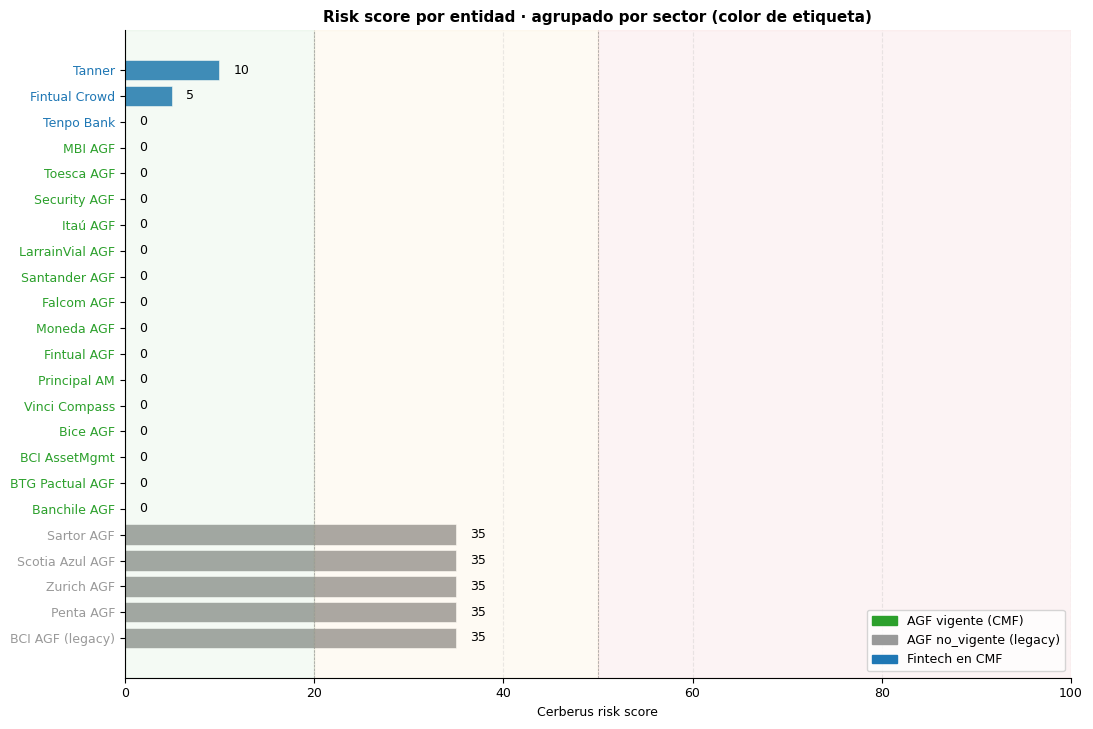

In [6]:
fig, ax = plt.subplots(figsize=(11, max(6, 0.32 * len(df))))
ordered = df.sort_values(["sector", "risk_score"], na_position="last")
sec_for_hint = dict(zip(df["hint"], df["sector"], strict=False))
colors = [SECTOR_COLORS.get(s, "#bbb") for s in ordered["sector"]]
bars = ax.barh(
    ordered["hint"],
    ordered["risk_score"].fillna(0),
    color=colors,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
)
for b, s in zip(bars, ordered["risk_score"], strict=False):
    if pd.notna(s):
        ax.text(s + 1.5, b.get_y() + b.get_height() / 2, f"{int(s)}", va="center", fontsize=9)
    else:
        ax.text(2, b.get_y() + b.get_height() / 2, "(n/a)", va="center", fontsize=8, color="#777")

# Color y-tick labels by sector
for i, h in enumerate(ordered["hint"]):
    sec = sec_for_hint.get(h, "")
    ax.get_yticklabels()[i].set_color(SECTOR_COLORS.get(sec, "#000"))

ax.axvspan(0, 20, alpha=0.05, color="#2ca02c")
ax.axvspan(20, 50, alpha=0.05, color="#f5a623")
ax.axvspan(50, 100, alpha=0.05, color="#d62728")
ax.axvline(20, color="#999", lw=0.5, ls="--")
ax.axvline(50, color="#999", lw=0.5, ls="--")
ax.set_xlim(0, 100)
ax.set_xlabel("Cerberus risk score")
ax.set_title("Risk score por entidad · agrupado por sector (color de etiqueta)")

legend = [mpatches.Patch(color=SECTOR_COLORS[k], label=SECTOR_LABEL[k]) for k in SECTOR_COLORS]
ax.legend(handles=legend, loc="lower right")
ax.grid(axis="x", alpha=0.25, linestyle="--")
plt.tight_layout()
plt.show()

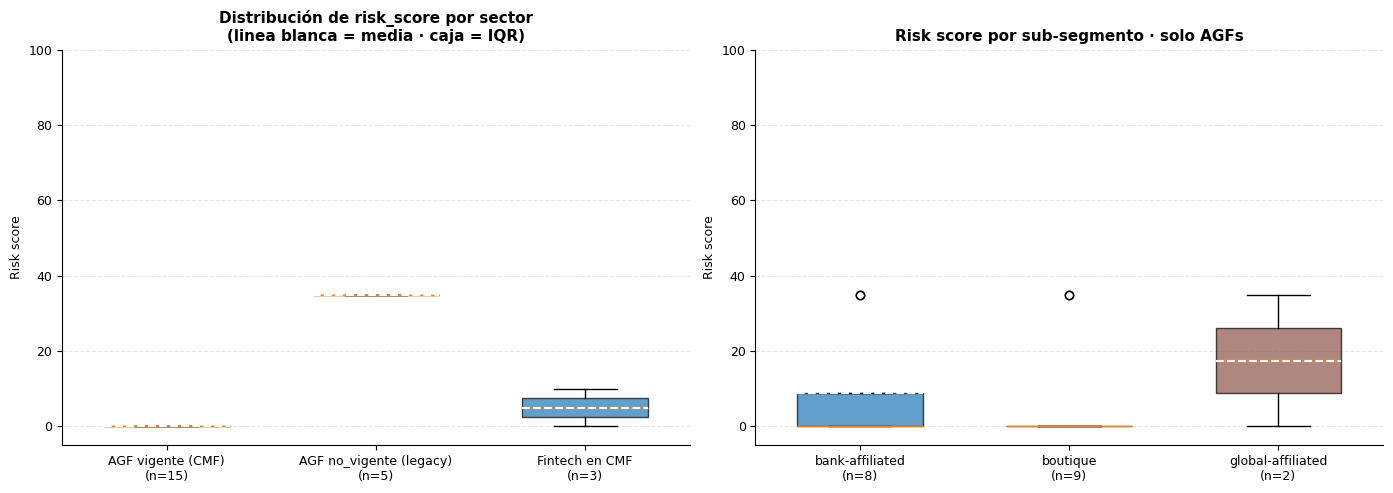


Estadísticas de risk_score por sector:
             count  mean  median  std  min  max
sector                                         
agf_legacy       5  35.0    35.0  0.0   35   35
agf_vigente     15   0.0     0.0  0.0    0    0
fintech_in       3   5.0     5.0  5.0    0   10


In [7]:
# Boxplot: distribución de risk_score por sector
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
data = []
labels = []
positions = []
colors_box = []
for i, sec in enumerate(["agf_vigente", "agf_legacy", "fintech_in"]):
    vals = df[df["sector"] == sec]["risk_score"].dropna().tolist()
    if vals:
        data.append(vals)
        labels.append(f"{SECTOR_LABEL[sec]}\n(n={len(vals)})")
        positions.append(i)
        colors_box.append(SECTOR_COLORS[sec])
bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.6,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    meanprops={"color": "white", "linewidth": 1.5},
)
for patch, c in zip(bp["boxes"], colors_box, strict=False):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_ylabel("Risk score")
ax.set_title("Distribución de risk_score por sector\n(linea blanca = media · caja = IQR)")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_ylim(-5, 100)

# Boxplot por sub_segment (solo sub-segmentos AGF para comparar régimen)
ax = axes[1]
agf = df[df["sector"].isin(["agf_vigente", "agf_legacy"])]
data2, labels2, positions2, colors2 = [], [], [], []
for i, sub in enumerate(["bank-affiliated", "boutique", "global-affiliated"]):
    vals = agf[agf["sub_segment"] == sub]["risk_score"].dropna().tolist()
    if vals:
        data2.append(vals)
        labels2.append(f"{sub}\n(n={len(vals)})")
        positions2.append(i)
        colors2.append(SUB_SEGMENT_COLORS.get(sub, "#999"))
if data2:
    bp = ax.boxplot(
        data2,
        positions=positions2,
        widths=0.6,
        patch_artist=True,
        showmeans=True,
        meanline=True,
        meanprops={"color": "white", "linewidth": 1.5},
    )
    for patch, c in zip(bp["boxes"], colors2, strict=False):
        patch.set_facecolor(c)
        patch.set_alpha(0.7)
    ax.set_xticks(positions2)
    ax.set_xticklabels(labels2)
ax.set_ylabel("Risk score")
ax.set_title("Risk score por sub-segmento · solo AGFs")
ax.grid(axis="y", alpha=0.3, linestyle="--")
ax.set_ylim(-5, 100)

plt.tight_layout()
plt.show()

print("\nEstadísticas de risk_score por sector:")
print(
    df.groupby("sector")["risk_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(1)
)

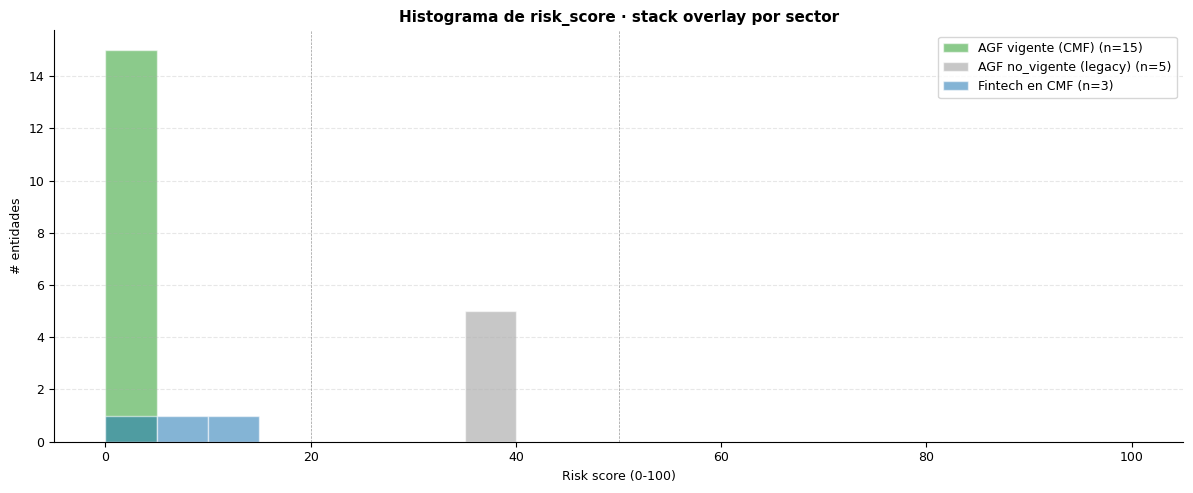

In [8]:
# Histograma + KDE (densidad) — distribución agregada
fig, ax = plt.subplots(figsize=(12, 5))
all_scores = df["risk_score"].dropna()
if len(all_scores) > 1:
    bins = np.linspace(0, 100, 21)
    for sec in ["agf_vigente", "agf_legacy", "fintech_in"]:
        vals = df[df["sector"] == sec]["risk_score"].dropna()
        if len(vals):
            ax.hist(
                vals,
                bins=bins,
                alpha=0.55,
                color=SECTOR_COLORS[sec],
                label=f"{SECTOR_LABEL[sec]} (n={len(vals)})",
                edgecolor="white",
            )
    ax.set_xlabel("Risk score (0-100)")
    ax.set_ylabel("# entidades")
    ax.set_title("Histograma de risk_score · stack overlay por sector")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    ax.axvline(20, color="#999", lw=0.5, ls="--")
    ax.axvline(50, color="#999", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

## 4 · Estado regulatorio · status, vigencia, antigüedad

`kyb.get` expone tres campos críticos:
- `status` — `vigente` / `no_vigente`
- `inscription_date` — fecha de inscripción CMF (sólo se materializa para emisores
  y ciertas entidades supervisadas)
- `cancellation_date` — fecha de cese (null si vigente)

Las AGFs **deben** tener inscripción CMF (Ley 20.712); las fintechs típicamente no
(viven en Ley Fintec, no en el registro CMF clásico).

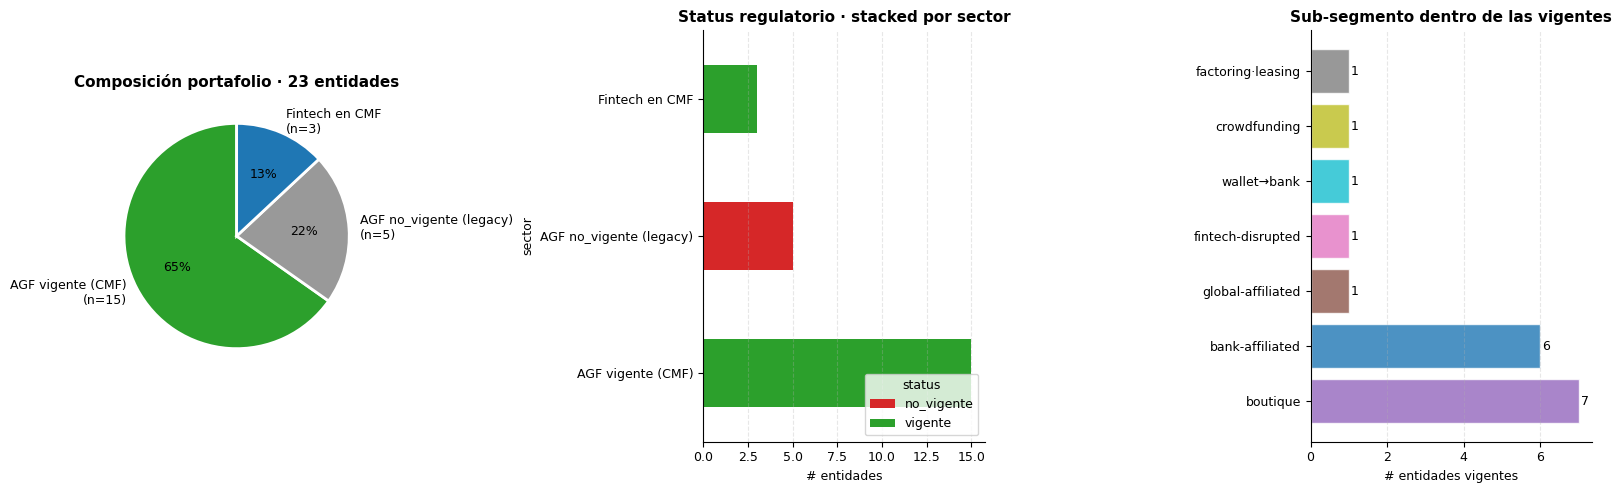


Distribución status × sector:
status       no_vigente  vigente
sector                          
agf_legacy            5        0
agf_vigente           0       15
fintech_in            0        3


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Pie: composición por sector
sector_counts = df["sector"].value_counts()
axes[0].pie(
    sector_counts.values,
    labels=[f"{SECTOR_LABEL[s]}\n(n={n})" for s, n in sector_counts.items()],
    colors=[SECTOR_COLORS.get(s, "#bbb") for s in sector_counts.index],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[0].set_title(f"Composición portafolio · {len(df)} entidades")

# (b) Stacked status x sector
df_sec_status = df.groupby(["sector", "status"]).size().unstack(fill_value=0)
df_sec_status = df_sec_status.reindex(["agf_vigente", "agf_legacy", "fintech_in"])
df_sec_status.plot(
    kind="barh", stacked=True, ax=axes[1], color={"vigente": "#2ca02c", "no_vigente": "#d62728"}
)
axes[1].set_yticklabels([SECTOR_LABEL[s] for s in df_sec_status.index])
axes[1].set_title("Status regulatorio · stacked por sector")
axes[1].set_xlabel("# entidades")
axes[1].legend(title="status", loc="lower right")
axes[1].grid(axis="x", alpha=0.3, linestyle="--")

# (c) Sub-segment breakdown of vigentes only
ax = axes[2]
vig = df[df["status"] == "vigente"]
sub_counts = vig["sub_segment"].value_counts()
colors3 = [SUB_SEGMENT_COLORS.get(s, "#999") for s in sub_counts.index]
ax.barh(sub_counts.index, sub_counts.values, color=colors3, alpha=0.8, edgecolor="white")
for i, v in enumerate(sub_counts.values):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
ax.set_title("Sub-segmento dentro de las vigentes")
ax.set_xlabel("# entidades vigentes")
ax.grid(axis="x", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

print("\nDistribución status x sector:")
print(df.groupby(["sector", "status"]).size().unstack(fill_value=0).to_string())

### Antigüedad CMF · longevidad regulatoria

`inscription_date` materializado da una idea del horizonte temporal de cada
AGF dentro del régimen CMF. Cuando NO está disponible es típicamente porque
el ingestor `cmf_universe_snapshot` no ha cubierto a esa entidad, lo que
ocurre con frecuencia en fintechs (zona gris).

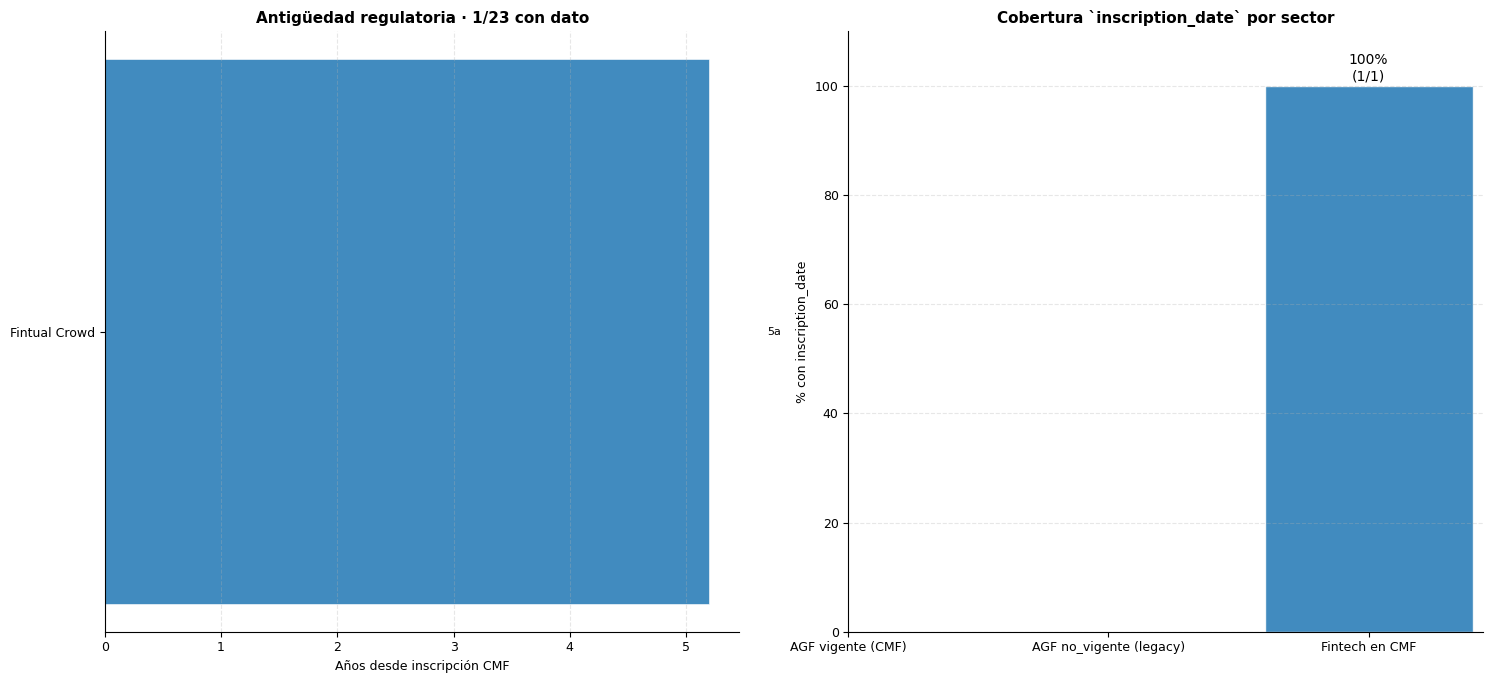


Más antigua:
  Fintual Crowd  inscrita 2021-03-01  (5 años)
Más joven:
  Fintual Crowd  inscrita 2021-03-01  (5 años)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.3 * len(df))))

# Antigüedad (año desde inscripción)
df_age = df.dropna(subset=["age_years"]).sort_values("age_years")
ax = axes[0]
if len(df_age):
    colors_age = [SECTOR_COLORS.get(s, "#999") for s in df_age["sector"]]
    bars = ax.barh(
        df_age["hint"],
        df_age["age_years"],
        color=colors_age,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.5,
    )
    for b, v in zip(bars, df_age["age_years"], strict=False):
        ax.text(v + 0.5, b.get_y() + b.get_height() / 2, f"{v:.0f}a", va="center", fontsize=8)
    ax.set_xlabel("Años desde inscripción CMF")
    ax.set_title(f"Antigüedad regulatoria · {len(df_age)}/{len(df)} con dato")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
else:
    ax.text(
        0.5, 0.5, "(sin datos de inscripción)", ha="center", va="center", transform=ax.transAxes
    )

# Cobertura inscription_date por sector
ax = axes[1]
cov = df.groupby("sector")["inscription_date"].agg(
    has=lambda s: s.notna().sum(),
    total="count",
)
cov["pct"] = (cov["has"] / cov["total"] * 100).round(0)
cov = cov.reindex(["agf_vigente", "agf_legacy", "fintech_in"])
xs = list(range(len(cov)))
colors4 = [SECTOR_COLORS[s] for s in cov.index]
ax.bar(xs, cov["pct"], color=colors4, alpha=0.85, edgecolor="white")
for i, (v, h, t) in enumerate(zip(cov["pct"], cov["has"], cov["total"], strict=False)):
    ax.text(i, v + 1, f"{v:.0f}%\n({h}/{t})", ha="center", fontsize=10)
ax.set_xticks(xs)
ax.set_xticklabels([SECTOR_LABEL[s] for s in cov.index])
ax.set_ylim(0, 110)
ax.set_ylabel("% con inscription_date")
ax.set_title("Cobertura `inscription_date` por sector")
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

print(f"\nMás antigua:")
if len(df_age):
    r = df_age.iloc[-1]
    print(f"  {r['hint']}  inscrita {r['inscription_date'].date()}  ({r['age_years']:.0f} años)")
print(f"Más joven:")
if len(df_age):
    r = df_age.iloc[0]
    print(f"  {r['hint']}  inscrita {r['inscription_date'].date()}  ({r['age_years']:.0f} años)")

## 5 · LEI canónico vía `entities` y grafo de ownership

Tres fuentes posibles del Legal Entity Identifier (GLEIF):

| Fuente | Recomendación |
|---|---|
| `entities.by_rut(rut).lei` | ✅ canónica (refresh GLEIF más reciente) |
| `entities.ownership(id).subject_lei` | ✅ canónica (mismo backing) |
| `kyb.get(rut).lei` | ⚠️ puede estar stale por caching del endpoint /kyb |

Para AGFs **bank-affiliated** esperamos LEI denso + grafo Level-2 GLEIF
(p.ej. Banchile→Banco de Chile→Citibank…). Para fintechs típicamente **sin LEI**.

In [11]:
async def fetch_entity_and_ownership(c, item):
    rut, hint, sector, sub, parent = item
    try:
        ent = await c.entities.by_rut(rut)
        own = await c.entities.ownership(ent["id"])
        return {
            "hint": hint,
            "rut": rut,
            "sector": sector,
            "sub_segment": sub,
            "parent_group": parent,
            "entity_id": ent["id"],
            "entity_lei": ent.get("lei"),
            "ownership": own,
            "entity": ent,
        }
    except Exception as e:
        return {
            "hint": hint,
            "rut": rut,
            "sector": sector,
            "sub_segment": sub,
            "parent_group": parent,
            "entity_id": None,
            "entity_lei": None,
            "ownership": {},
            "entity": {},
            "err": str(e)[:120],
        }


ownerships = asyncio.run(gather_throttled(fetch_entity_and_ownership, PORTFOLIO, concurrency=5))

# Materialize entity_lei into df
df["entity_lei"] = df["rut"].map({o["rut"]: o.get("entity_lei") for o in ownerships})
df["has_lei"] = df["entity_lei"].notna()
df["entity_id"] = df["rut"].map({o["rut"]: o.get("entity_id") for o in ownerships})

# Build LEI table
lei_rows = []
for o in ownerships:
    own = o.get("ownership") or {}
    subj = own.get("subject_lei")
    if isinstance(subj, dict):
        subj = subj.get("lei")
    profile = next(p for p in profiles if p["rut"] == o["rut"])
    lei_rows.append(
        {
            "entidad": o["hint"],
            "sector": o["sector"],
            "sub_segment": o["sub_segment"],
            "kyb.lei": profile.get("lei") or "—",
            "entity.lei": o.get("entity_lei") or "—",
            "subject_lei": subj or "—",
            "direct_parent": "✓" if own.get("direct_parent") else "—",
            "ultimate_parent": "✓" if own.get("ultimate_parent") else "—",
        }
    )
df_lei = pd.DataFrame(lei_rows)
df_lei

,entidad,sector,sub_segment,kyb.lei,entity.lei,subject_lei,direct_parent,ultimate_parent
0,Banchile AGF,agf_vigente,bank-affiliated,549300PFI630K07QHI12,549300PFI630K07QHI12,549300PFI630K07QHI12,—,—
1,BTG Pactual AGF,agf_vigente,boutique,549300ZVBGRGB6OL8759,549300ZVBGRGB6OL8759,549300ZVBGRGB6OL8759,—,—
2,BCI AssetMgmt,agf_vigente,bank-affiliated,2549003PWNEB1P1TAL95,2549003PWNEB1P1TAL95,2549003PWNEB1P1TAL95,—,—
3,Bice AGF,agf_vigente,bank-affiliated,2549007CE0XCD4HUKN58,2549007CE0XCD4HUKN58,2549007CE0XCD4HUKN58,—,—
4,Vinci Compass,agf_vigente,boutique,254900O3DCTK2GPEA896,254900O3DCTK2GPEA896,254900O3DCTK2GPEA896,—,—
5,Principal AM,agf_vigente,global-affiliated,549300R9YHEPJA5WOV09,549300R9YHEPJA5WOV09,549300R9YHEPJA5WOV09,—,—
6,Fintual AGF,agf_vigente,fintech-disrupted,2549004RUEQB0XKNTI34,2549004RUEQB0XKNTI34,2549004RUEQB0XKNTI34,—,—
7,Moneda AGF,agf_vigente,boutique,549300O3RIGG8W2NLH04,549300O3RIGG8W2NLH04,549300O3RIGG8W2NLH04,—,—
8,Falcom AGF,agf_vigente,boutique,254900AT2YKV4Q01CM92,254900AT2YKV4Q01CM92,254900AT2YKV4Q01CM92,—,—
9,Santander AGF,agf_vigente,bank-affiliated,9845003D989574C04278,9845003D989574C04278,9845003D989574C04278,—,—


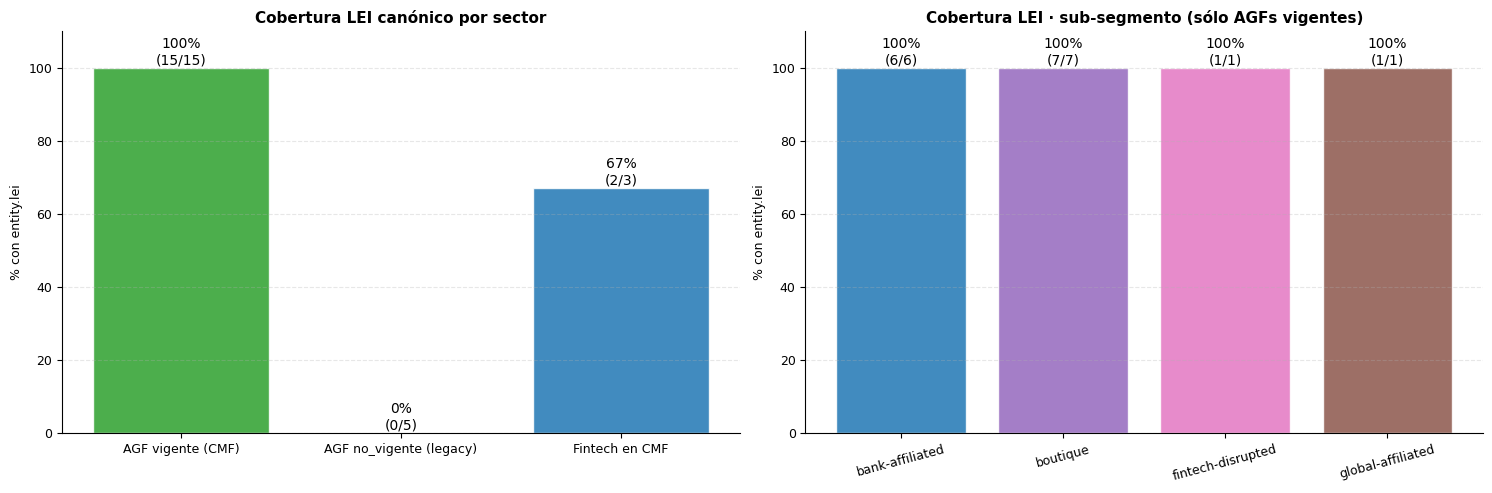


Discrepancias kyb.lei vs entity.lei: 0/23


In [12]:
# Cobertura LEI: por sector y por sub_segment dentro de AGFs
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Por sector
ax = axes[0]
cov = df.groupby("sector")["has_lei"].agg(["sum", "count"])
cov["pct"] = (cov["sum"] / cov["count"] * 100).round(0)
cov = cov.reindex(["agf_vigente", "agf_legacy", "fintech_in"])
xs = list(range(len(cov)))
colors_c = [SECTOR_COLORS[s] for s in cov.index]
bars = ax.bar(xs, cov["pct"], color=colors_c, alpha=0.85, edgecolor="white")
for i, (v, s_, t) in enumerate(zip(cov["pct"], cov["sum"], cov["count"], strict=False)):
    ax.text(i, v + 1, f"{v:.0f}%\n({s_}/{t})", ha="center", fontsize=10)
ax.set_xticks(xs)
ax.set_xticklabels([SECTOR_LABEL[s] for s in cov.index])
ax.set_ylim(0, 110)
ax.set_ylabel("% con entity.lei")
ax.set_title("Cobertura LEI canónico por sector")
ax.grid(axis="y", alpha=0.3, linestyle="--")

# Por sub_segment dentro de AGFs vigentes
ax = axes[1]
agf_v = df[df["sector"] == "agf_vigente"]
cov2 = agf_v.groupby("sub_segment")["has_lei"].agg(["sum", "count"])
cov2["pct"] = (cov2["sum"] / cov2["count"] * 100).round(0)
xs2 = list(range(len(cov2)))
colors_d = [SUB_SEGMENT_COLORS.get(s, "#999") for s in cov2.index]
ax.bar(xs2, cov2["pct"], color=colors_d, alpha=0.85, edgecolor="white")
for i, (v, s_, t) in enumerate(zip(cov2["pct"], cov2["sum"], cov2["count"], strict=False)):
    ax.text(i, v + 1, f"{v:.0f}%\n({s_}/{t})", ha="center", fontsize=10)
ax.set_xticks(xs2)
ax.set_xticklabels(cov2.index, rotation=15)
ax.set_ylim(0, 110)
ax.set_ylabel("% con entity.lei")
ax.set_title("Cobertura LEI · sub-segmento (sólo AGFs vigentes)")
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# Compare kyb.lei vs entity.lei discrepancies
discrepancies = []
for o in ownerships:
    profile = next(p for p in profiles if p["rut"] == o["rut"])
    kyb_lei = profile.get("lei")
    ent_lei = o.get("entity_lei")
    if (kyb_lei or "") != (ent_lei or ""):
        discrepancies.append(
            {
                "entidad": o["hint"],
                "kyb.lei": kyb_lei or "(null)",
                "entity.lei": ent_lei or "(null)",
            }
        )
print(f"\nDiscrepancias kyb.lei vs entity.lei: {len(discrepancies)}/{len(ownerships)}")
for d in discrepancies[:6]:
    print(f"  {d['entidad']:18s}  kyb='{d['kyb.lei']}'  entity='{d['entity.lei']}'")

### Grafo de ownership · ultimate parents

Cuando el LEI canónico está disponible, GLEIF Level-2 nos da el grafo
corporativo. Mostramos el `ultimate_parent` (cuando existe) por entidad —
revela las cabeza-de-grupo internacionales detrás de las AGFs locales.

In [13]:
ownership_graph = []
for o in ownerships:
    own = o.get("ownership") or {}
    dp = own.get("direct_parent")
    up = own.get("ultimate_parent")
    dp_name = dp.get("legal_name") if isinstance(dp, dict) else None
    up_name = up.get("legal_name") if isinstance(up, dict) else None
    dp_ctry = dp.get("country") if isinstance(dp, dict) else None
    up_ctry = up.get("country") if isinstance(up, dict) else None
    ownership_graph.append(
        {
            "entidad": o["hint"],
            "sector": o["sector"],
            "direct_parent": (dp_name or "—")[:45],
            "direct_country": dp_ctry or "—",
            "ultimate_parent": (up_name or "—")[:45],
            "ultimate_country": up_ctry or "—",
        }
    )
df_own = pd.DataFrame(ownership_graph)

# Country distribution of ultimate parents
country_dist = df_own[df_own["ultimate_country"] != "—"]["ultimate_country"].value_counts()
print("\nDistribución de países de los ultimate parents:")
print(country_dist.to_string())

if len(country_dist):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(country_dist.index, country_dist.values, color="#5b9bd5", alpha=0.85, edgecolor="white")
    for i, v in enumerate(country_dist.values):
        ax.text(v + 0.05, i, str(v), va="center", fontsize=10)
    ax.set_title(f"Ultimate parent · país de origen ({country_dist.sum()} con dato)")
    ax.set_xlabel("# entidades")
    ax.grid(axis="x", alpha=0.3, linestyle="--")
    plt.tight_layout()
    plt.show()

df_own[df_own["ultimate_parent"] != "—"][
    ["entidad", "sector", "ultimate_parent", "ultimate_country"]
]


Distribución de países de los ultimate parents:
Series([], )


,entidad,sector,ultimate_parent,ultimate_country


## 6 · Composición de directorios

Las AGFs deben publicar directorio en CMF (Norma de Gobierno Corporativo, NCG 386).
Las fintechs no tienen esa obligación a menos que estén inscritas como PSF
bajo Ley Fintec con el servicio relevante.

> Nota de cobertura: el ingestor `cmf_directores_gerentes` cubre primariamente
> emisores y SCB; AGFs típicamente quedan con `n_directors=0` no porque no tengan
> directorio sino porque no son objetivo del ingestor actual. Los hechos esenciales
> y el grafo de ownership compensan parcialmente este gap.

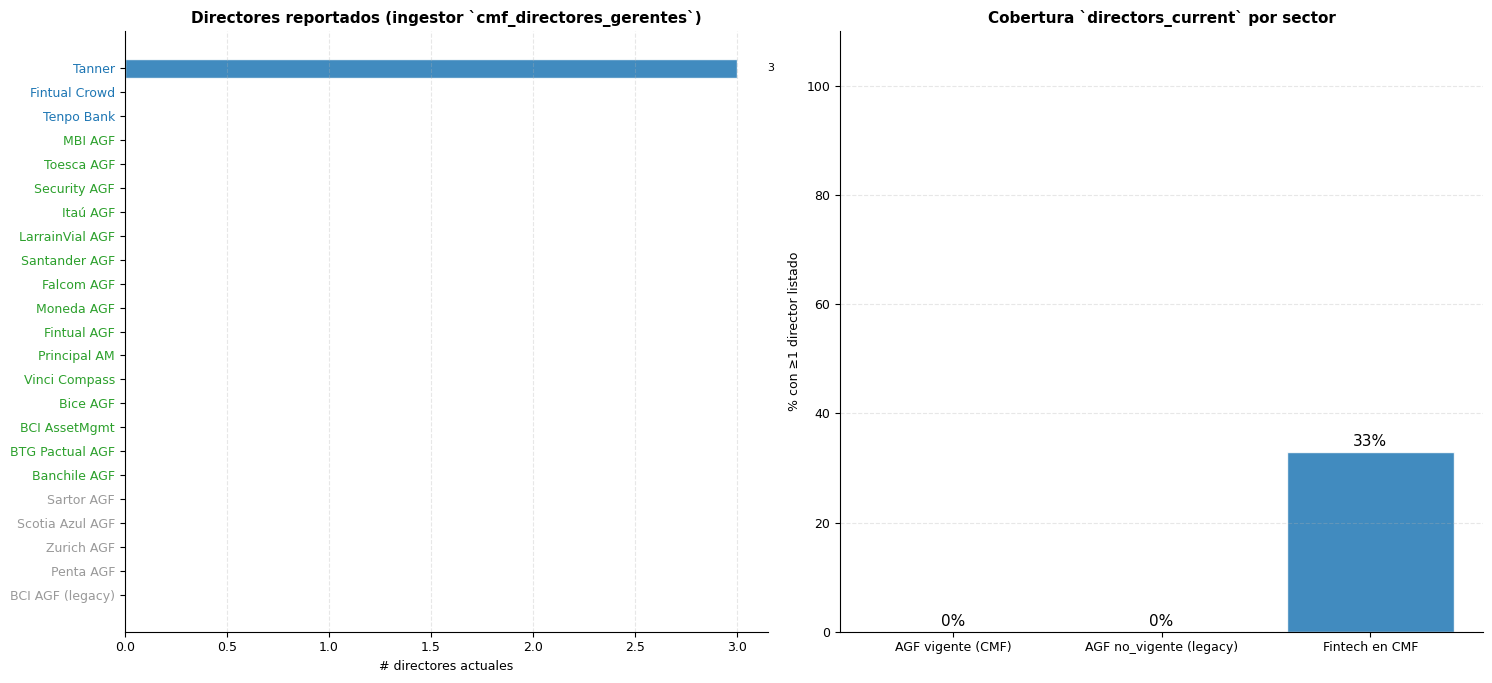


Total directores listados: 3


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, max(5, 0.3 * len(df))))

ax = axes[0]
df_dir = df.sort_values(["sector", "n_directors"])
colors_d = [SECTOR_COLORS.get(s, "#999") for s in df_dir["sector"]]
bars = ax.barh(df_dir["hint"], df_dir["n_directors"], color=colors_d, alpha=0.85, edgecolor="white")
for b, n in zip(bars, df_dir["n_directors"], strict=False):
    if n > 0:
        ax.text(n + 0.15, b.get_y() + b.get_height() / 2, str(int(n)), va="center", fontsize=8)
sec_for_hint = dict(zip(df["hint"], df["sector"], strict=False))
for i, h in enumerate(df_dir["hint"]):
    ax.get_yticklabels()[i].set_color(SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#000"))
ax.set_xlabel("# directores actuales")
ax.set_title("Directores reportados (ingestor `cmf_directores_gerentes`)")
ax.grid(axis="x", alpha=0.3, linestyle="--")

# Bar: cobertura de directorio por sector
ax = axes[1]
cov = (
    df.groupby("sector")
    .apply(lambda g: (g["n_directors"] > 0).mean() * 100, include_groups=False)
    .round(0)
)
cov = cov.reindex(["agf_vigente", "agf_legacy", "fintech_in"])
xs = list(range(len(cov)))
colors_e = [SECTOR_COLORS[s] for s in cov.index]
ax.bar(xs, cov.values, color=colors_e, alpha=0.85, edgecolor="white")
for i, v in enumerate(cov.values):
    ax.text(i, v + 1, f"{v:.0f}%", ha="center", fontsize=11)
ax.set_xticks(xs)
ax.set_xticklabels([SECTOR_LABEL[s] for s in cov.index])
ax.set_ylim(0, 110)
ax.set_ylabel("% con ≥1 director listado")
ax.set_title("Cobertura `directors_current` por sector")
ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

# Build all_dirs
all_dirs = []
for p in profiles:
    for d in p["_directors"]:
        all_dirs.append(
            {
                "entidad": p["hint"],
                "sector": p["sector"],
                "cargo": d.get("cargo"),
                "nombre": d.get("nombre"),
                "rut": d.get("persona_rut"),
                "fecha_inicio": d.get("fecha_inicio"),
            }
        )
df_all_dirs = pd.DataFrame(all_dirs)
print(f"\nTotal directores listados: {len(df_all_dirs)}")


Personas en >1 entidad del portafolio: 0


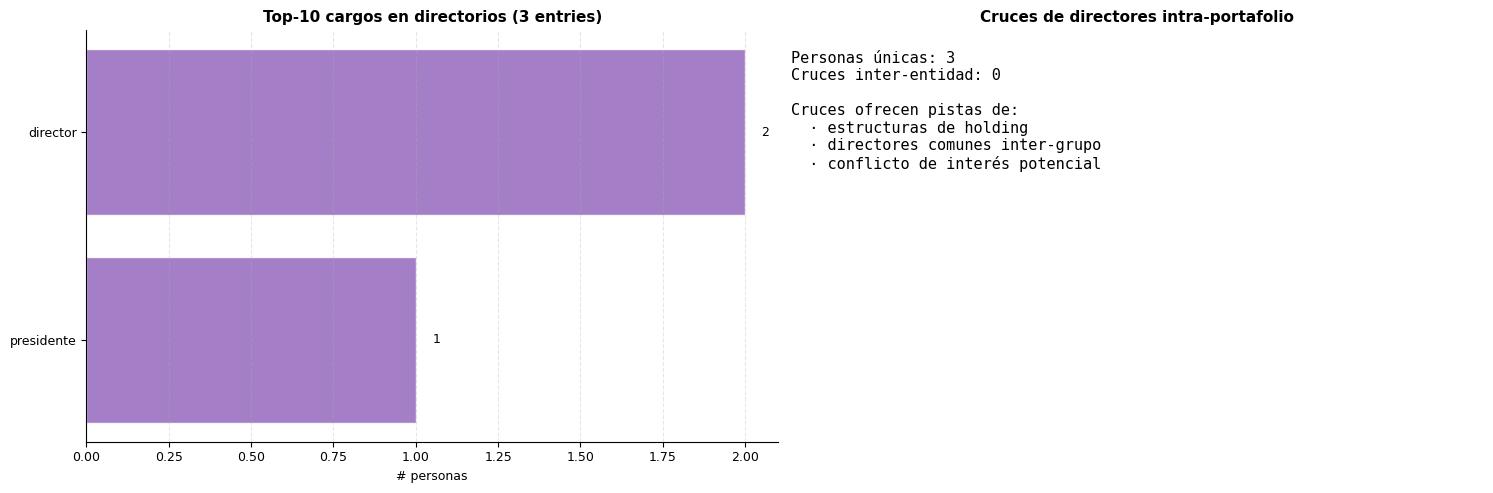

In [15]:
# Cargo distribution + cruces inter-entidad
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
if len(df_all_dirs):
    cargos = df_all_dirs["cargo"].fillna("(sin cargo)").value_counts().head(10)
    ax.barh(cargos.index, cargos.values, color="#9467bd", alpha=0.85, edgecolor="white")
    for i, v in enumerate(cargos.values):
        ax.text(v + 0.05, i, str(v), va="center", fontsize=9)
    ax.set_title(f"Top-10 cargos en directorios ({len(df_all_dirs)} entries)")
    ax.set_xlabel("# personas")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3, linestyle="--")
else:
    ax.text(0.5, 0.5, "(sin datos de cargos)", ha="center", va="center", transform=ax.transAxes)

ax = axes[1]
person_to_posts: dict[str, list] = {}
for d in all_dirs:
    rut = d["rut"]
    if rut:
        person_to_posts.setdefault(rut, []).append(d)
multi = {
    rut: posts for rut, posts in person_to_posts.items() if len({p["entidad"] for p in posts}) > 1
}
print(f"\nPersonas en >1 entidad del portafolio: {len(multi)}")
if multi:
    print("Cruces detectados:")
    for rut, posts in list(multi.items())[:10]:
        nombre = posts[0]["nombre"]
        ents = sorted({p["entidad"] for p in posts})
        secs = sorted({p["sector"] for p in posts})
        print(f"  {rut}  {nombre[:35]:35s}  → {len(ents)} entidades  ({', '.join(secs)})")
        print(f"           {ents}")
ax.text(
    0.0,
    0.95,
    f"Personas únicas: {len(person_to_posts)}\n"
    f"Cruces inter-entidad: {len(multi)}\n\n"
    + (
        "Cruces ofrecen pistas de:\n"
        "  · estructuras de holding\n"
        "  · directores comunes inter-grupo\n"
        "  · conflicto de interés potencial"
    ),
    ha="left",
    va="top",
    fontsize=11,
    transform=ax.transAxes,
    family="monospace",
)
ax.axis("off")
ax.set_title("Cruces de directores intra-portafolio")

plt.tight_layout()
plt.show()

## 7 · Sanciones CMF · análisis multi-dimensional

Pulleamos sanciones detalladas por entidad vía `entities.sanctions(entity_id)`
y construimos seis vistas: counts por sector, distribución de estado, heatmap
entidad×año, recencia (días desde la última), personas naturales vs corporativas
y análisis de texto sobre `infraccion`.

In [16]:
async def fetch_sanctions(c, item):
    rut, hint, sector, sub, parent = item
    try:
        ent = await c.entities.by_rut(rut)
        eid = ent["id"]
        sancs = await c.entities.sanctions(eid)
        return {
            "hint": hint,
            "rut": rut,
            "sector": sector,
            "sub_segment": sub,
            "parent_group": parent,
            "entity_id": eid,
            "sanctions": sancs,
        }
    except Exception as e:
        return {
            "hint": hint,
            "rut": rut,
            "sector": sector,
            "sub_segment": sub,
            "parent_group": parent,
            "sanctions": [],
            "err": str(e)[:120],
        }


bank_sancs = asyncio.run(gather_throttled(fetch_sanctions, PORTFOLIO, concurrency=5))

sanc_rows = []
for bs in bank_sancs:
    for s in bs["sanctions"]:
        sanc_rows.append(
            {
                "entidad": bs["hint"],
                "sector": bs["sector"],
                "sub_segment": bs["sub_segment"],
                "id": s.get("cmf_resolucion_id"),
                "fecha": s.get("fecha_resolucion"),
                "estado": s.get("estado"),
                "multa_uf": s.get("multa_uf"),
                "multa_clp": s.get("multa_clp"),
                "persona_natural": s.get("persona_natural_nombre"),
                "infraccion": s.get("infraccion") or "",
            }
        )
df_sanc = pd.DataFrame(sanc_rows)
if len(df_sanc):
    df_sanc["fecha"] = pd.to_datetime(df_sanc["fecha"], errors="coerce")
    df_sanc["año"] = df_sanc["fecha"].dt.year
    df_sanc["multa_uf_num"] = pd.to_numeric(df_sanc["multa_uf"], errors="coerce")
    df_sanc["multa_clp_num"] = pd.to_numeric(df_sanc["multa_clp"], errors="coerce")

print(f"Sanciones en el portafolio: {len(df_sanc)}")
if len(df_sanc):
    print(f"Rango temporal: {df_sanc['fecha'].min().date()} → {df_sanc['fecha'].max().date()}")
    print(f"\nPor sector:")
    by_sec = df_sanc.groupby("sector").size().sort_values(ascending=False)
    for s, n in by_sec.items():
        print(f"  {SECTOR_LABEL.get(s, s):28s}  {n:>3}")
    print(f"\nPor estado:")
    print(df_sanc["estado"].value_counts().to_string())

Sanciones en el portafolio: 0


In [17]:
if len(df_sanc):
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # (a) Sanctions per entity, stacked by estado, ordered by sector
    ax = axes[0, 0]
    order = df.sort_values(["sector", "hint"])["hint"].tolist()
    estado_pivot = (
        df_sanc.groupby(["entidad", "estado"])
        .size()
        .unstack(fill_value=0)
        .reindex(order)
        .fillna(0)
        .astype(int)
    )
    if len(estado_pivot):
        estado_pivot["total"] = estado_pivot.drop(
            columns=[c for c in estado_pivot.columns if c == "total"], errors="ignore"
        ).sum(axis=1)
        estado_pivot = estado_pivot[estado_pivot["total"] > 0]
        if len(estado_pivot):
            estado_cols = [c for c in estado_pivot.columns if c != "total"]
            estado_palette = {
                "vigente": "#d62728",
                "firme": "#1f77b4",
                "prescrita": "#999",
                "extinguida": "#2ca02c",
                "anulada": "#9467bd",
            }
            estado_pivot = estado_pivot.sort_values("total")
            left = pd.Series(0, index=estado_pivot.index)
            for est in estado_cols:
                ax.barh(
                    estado_pivot.index,
                    estado_pivot[est],
                    left=left,
                    label=est,
                    color=estado_palette.get(est, "#bbb"),
                    alpha=0.85,
                    edgecolor="white",
                    linewidth=0.5,
                )
                left += estado_pivot[est]
            for i, t in enumerate(estado_pivot["total"]):
                ax.text(t + 0.1, i, str(int(t)), va="center", fontsize=8)
            ax.set_title("Sanciones por entidad · stacked por estado")
            ax.set_xlabel("# sanciones")
            ax.legend(loc="lower right")
            ax.grid(axis="x", alpha=0.3, linestyle="--")

    # (b) Pie: estado distribution
    ax = axes[0, 1]
    est_total = df_sanc["estado"].fillna("(sin estado)").value_counts()
    colors_e = (
        [estado_palette.get(s, "#bbb") for s in est_total.index]
        if "estado_palette" in dir()
        else None
    )
    ax.pie(
        est_total.values,
        labels=[f"{s}\n({n})" for s, n in est_total.items()],
        colors=colors_e,
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
    )
    ax.set_title(f"Distribución global de estado · {len(df_sanc)} sanciones")

    # (c) Per-sector aggregate sanctions count
    ax = axes[1, 0]
    sec_agg = df_sanc.groupby("sector").size()
    sec_agg = sec_agg.reindex(["agf_vigente", "agf_legacy", "fintech_in"]).fillna(0).astype(int)
    xs = list(range(len(sec_agg)))
    colors_s = [SECTOR_COLORS[s] for s in sec_agg.index]
    bars = ax.bar(xs, sec_agg.values, color=colors_s, alpha=0.85, edgecolor="white")
    for i, v in enumerate(sec_agg.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontsize=11)
    ax.set_xticks(xs)
    ax.set_xticklabels([SECTOR_LABEL[s] for s in sec_agg.index])
    ax.set_ylabel("# sanciones")
    ax.set_title("Sanciones agregadas por sector")
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    # (d) Per-sub_segment within AGFs
    ax = axes[1, 1]
    agf_only = df_sanc[df_sanc["sector"].isin(["agf_vigente", "agf_legacy"])]
    sub_agg = agf_only.groupby("sub_segment").size().sort_values(ascending=False)
    if len(sub_agg):
        ys = list(range(len(sub_agg)))
        colors_x = [SUB_SEGMENT_COLORS.get(s, "#999") for s in sub_agg.index]
        ax.barh(ys, sub_agg.values, color=colors_x, alpha=0.85, edgecolor="white")
        for i, v in enumerate(sub_agg.values):
            ax.text(v + 0.1, i, str(v), va="center", fontsize=10)
        ax.set_yticks(ys)
        ax.set_yticklabels(sub_agg.index)
    ax.set_xlabel("# sanciones")
    ax.set_title("Sanciones por sub-segmento (sólo AGFs)")
    ax.grid(axis="x", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()
else:
    print("Sin sanciones en el portafolio para graficar.")

Sin sanciones en el portafolio para graficar.


### Heatmap entidad × año · cuándo se sancionó cada quien

In [18]:
if len(df_sanc) and df_sanc["año"].notna().any():
    order = df.sort_values(["sector", "hint"])["hint"].tolist()
    pivot = (
        df_sanc.dropna(subset=["año"])
        .groupby(["entidad", "año"])
        .size()
        .unstack(fill_value=0)
        .reindex(order)
        .fillna(0)
        .astype(int)
    )
    pivot = pivot.loc[pivot.sum(axis=1) > 0]  # only entidades with sanctions
    all_years = list(range(int(df_sanc["año"].min()), int(df_sanc["año"].max()) + 1))
    pivot = pivot.reindex(columns=all_years, fill_value=0)

    fig, ax = plt.subplots(figsize=(14, max(4, 0.4 * len(pivot) + 1)))
    im = ax.imshow(pivot.values, cmap="OrRd", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    sec_for_hint = dict(zip(df["hint"], df["sector"], strict=False))
    for i, h in enumerate(pivot.index):
        ax.get_yticklabels()[i].set_color(SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#000"))
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = int(pivot.iloc[i, j])
            if v > 0:
                ax.text(
                    j,
                    i,
                    str(v),
                    ha="center",
                    va="center",
                    color="white" if v > pivot.values.max() * 0.5 else "black",
                    fontsize=8,
                    fontweight="bold",
                )
    ax.set_title(f"Sanciones x año · heatmap (nombres coloreados por sector)")
    fig.colorbar(im, ax=ax, label="# sanciones por celda")
    plt.tight_layout()
    plt.show()
else:
    print("Sin suficientes sanciones para heatmap año x entidad.")

Sin suficientes sanciones para heatmap año × entidad.


### Recencia · días desde la última sanción

Memoria reciente regulatoria. Una entidad cuya última sanción fue hace 30 días
está en una situación distinta a una cuya última fue hace 8 años.

In [19]:
if len(df_sanc):
    today_ts = pd.Timestamp.today().normalize()
    last_per = (
        df_sanc.dropna(subset=["fecha"])
        .sort_values("fecha", ascending=False)
        .drop_duplicates("entidad")[["entidad", "sector", "fecha", "estado"]]
    )
    last_per["dias_desde"] = (today_ts - last_per["fecha"]).dt.days
    # Include all entidades, even those without sanctions
    all_e = pd.DataFrame({"entidad": df["hint"], "sector": df["sector"]})
    last_per = all_e.merge(
        last_per[["entidad", "fecha", "estado", "dias_desde"]], on="entidad", how="left"
    )
    last_per = last_per.sort_values(["dias_desde"], na_position="last")
    last_per = last_per[last_per["dias_desde"].notna()]  # solo las que tienen sanción
    if len(last_per):
        fig, ax = plt.subplots(figsize=(13, max(4, 0.35 * len(last_per))))
        colors_r = []
        for d in last_per["dias_desde"]:
            if d <= 365:
                colors_r.append("#d62728")
            elif d <= 365 * 3:
                colors_r.append("#f5a623")
            elif d <= 365 * 5:
                colors_r.append("#bbbb44")
            else:
                colors_r.append("#2ca02c")
        bars = ax.barh(
            last_per["entidad"],
            last_per["dias_desde"],
            color=colors_r,
            alpha=0.85,
            edgecolor="white",
        )
        for b, d in zip(bars, last_per["dias_desde"], strict=False):
            ax.text(
                d + 30,
                b.get_y() + b.get_height() / 2,
                f"{int(d)} días ({int(d / 365.25)}a)",
                va="center",
                fontsize=8,
            )
        ax.axvline(365, color="#999", lw=0.5, ls="--", label="< 1 año")
        ax.axvline(365 * 3, color="#999", lw=0.5, ls=":", label="< 3 años")
        ax.axvline(365 * 5, color="#999", lw=0.5, ls=":", label="< 5 años")
        ax.set_xlabel("Días desde última sanción")
        ax.set_title(f"Recencia regulatoria · {len(last_per)} entidades con sanciones")
        ax.legend(loc="lower right")
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        plt.tight_layout()
        plt.show()

### Multas · personas naturales · análisis de texto

In [20]:
if len(df_sanc):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Multa magnitudes
    ax = axes[0]
    multa_uf = df_sanc["multa_uf_num"].dropna()
    if len(multa_uf):
        ax.hist(multa_uf, bins=20, color="#1f77b4", alpha=0.85, edgecolor="white")
        ax.set_xlabel("Multa (UF)")
        ax.set_ylabel("# sanciones")
        ax.set_title(
            f"Distribución de magnitud de multas · {len(multa_uf)}/{len(df_sanc)} con dato"
        )
        ax.grid(axis="y", alpha=0.3, linestyle="--")
    else:
        ax.text(
            0.5,
            0.5,
            "Sin multas con valor numérico\n(regex de extractor falla en mayoría)",
            ha="center",
            va="center",
            transform=ax.transAxes,
            fontsize=11,
        )
        ax.set_xticks([])
        ax.set_yticks([])

    # Persona natural vs corporativa
    ax = axes[1]
    pn = df_sanc["persona_natural"].notna().sum()
    co = (~df_sanc["persona_natural"].notna()).sum()
    ax.pie(
        [co, pn],
        labels=[f"Corporativas\n({co})", f"Persona natural\n({pn})"],
        colors=["#5b9bd5", "#9467bd"],
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
    )
    ax.set_title(f"Sanción dirigida a la entidad o a un individuo")

    plt.tight_layout()
    plt.show()

In [21]:
# Análisis de texto · top palabras + bigramas
STOP_WORDS = {
    "PARA",
    "SOBRE",
    "DESDE",
    "HASTA",
    "COMO",
    "ESTOS",
    "ESTAS",
    "ENTRE",
    "TODA",
    "NIVEL",
    "CONTRA",
    "DICHA",
    "CUANDO",
    "OTROS",
    "MISMO",
    "MISMA",
    "ESTA",
    "ESTE",
    "TODOS",
    "TODAS",
    "SECCIÓN",
    "CAPÍTULO",
    "DEBE",
    "DEBER",
    "HACER",
    "SERÁ",
    "PUEDE",
    "OFICIO",
    "DESPUES",
    "SOCIEDAD",
    "ANÓNIMA",
    "RESPECTO",
    "CASO",
    "HECHOS",
    "ACCIÓN",
    "SEGÚN",
    "CUYO",
    "FORMA",
    "PARTE",
    "DICHO",
    "DICHOS",
    "DEBIDO",
    "DURANTE",
    "PRESENTE",
    "PRESENTES",
    "APLICA",
    "APLICACIÓN",
    "APLICAN",
    "SANCIÓN",
    "MULTA",
    "SANCIONES",
    "INSTITUCIÓN",
    "INSTITUCIONES",
    "DECRETO",
    "NÚMERO",
    "SEÑOR",
    "SEÑORA",
    "FORMULA",
    "CARGO",
    "CARGOS",
    "ARTÍCULO",
    "ARTÍCULOS",
    "ARTICULO",
    "ARTICULOS",
    "MÁS",
    "MENOS",
    "TANTO",
    "ASIMISMO",
    "SOLO",
    "SOLAMENTE",
    "SIENDO",
    "FUERON",
    "ELLO",
    "CIRCUNSTANCIA",
    "CIRCUNSTANCIAS",
    "TÉRMINO",
    "TÉRMINOS",
    "CUANTO",
    "ADMINISTRADORA",
    "FONDOS",
    "FONDO",
    "GENERAL",
    "COMPAÑÍA",
    "SECTOR",
    "ESTABLECIDO",
    "ESTABLECIDOS",
    "INFRACCIÓN",
    "NORMA",
    "NORMATIVA",
}


def _tokenize_es(text: str) -> list[str]:
    return [w for w in re.findall(r"[A-ZÁÉÍÓÚÑ]{4,}", (text or "").upper()) if w not in STOP_WORDS]


all_words: list[str] = []
all_bigrams: list[tuple[str, str]] = []
if len(df_sanc):
    for txt in df_sanc["infraccion"]:
        toks = _tokenize_es(str(txt))
        all_words.extend(toks)
        for i in range(len(toks) - 1):
            all_bigrams.append((toks[i], toks[i + 1]))

if all_words:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    # Top 25 unigrams
    top_uni = Counter(all_words).most_common(25)
    if top_uni:
        words, counts = zip(*top_uni, strict=False)
        ax = axes[0]
        ax.barh(
            list(words[::-1]), list(counts[::-1]), color="#5b9bd5", alpha=0.85, edgecolor="white"
        )
        for i, c in enumerate(counts[::-1]):
            ax.text(c + 0.2, i, str(c), va="center", fontsize=8)
        ax.set_title(f"Top-25 palabras (≥4 chars) en `infraccion`")
        ax.set_xlabel("# apariciones")
        ax.grid(axis="x", alpha=0.3, linestyle="--")

    # Top 20 bigrams
    top_bi = Counter(all_bigrams).most_common(20)
    if top_bi:
        bgs, counts = zip(*top_bi, strict=False)
        labels = [f"{a} {b}" for a, b in bgs]
        ax = axes[1]
        ax.barh(labels[::-1], list(counts[::-1]), color="#ff7f0e", alpha=0.85, edgecolor="white")
        for i, c in enumerate(counts[::-1]):
            ax.text(c + 0.05, i, str(c), va="center", fontsize=8)
        ax.set_title("Top-20 bigramas frecuentes")
        ax.set_xlabel("# apariciones")
        ax.grid(axis="x", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()
    print(
        f"\nTokens totales: {len(all_words)}  ·  únicos: {len(set(all_words))}  ·  bigramas: {len(all_bigrams)}"
    )

## 8 · Cross-reference contra OFAC · UN · EU

`sanctions.cross_reference(name=…, threshold=θ)` hace fuzzy match contra las
listas internacionales. Hacemos:

1. **Threshold sweep** sobre Banchile AGF para confirmar que 0.85 es la zona
   óptima signal/noise (consistente con los notebooks de bancos y telecoms).
2. **Aplicación @0.85 a las 23 entidades** del portafolio.
3. **Distribución por fuente** (OFAC, UN, EU) y por sector.

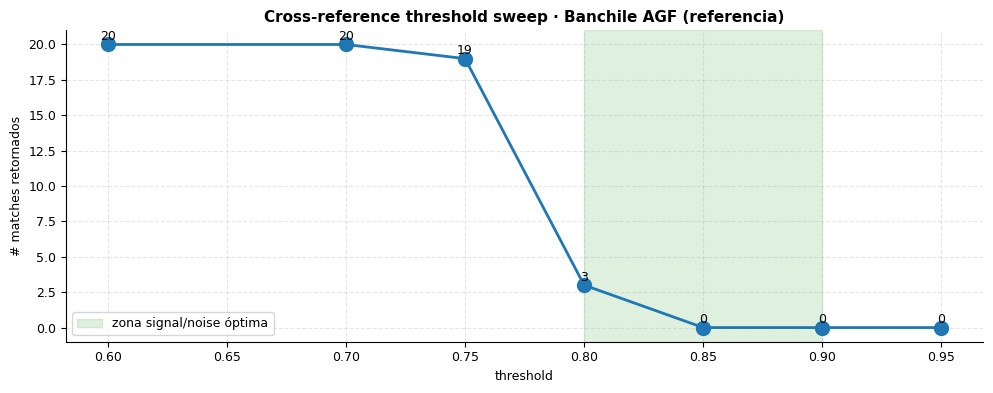

 threshold  n_matches
      0.60         20
      0.70         20
      0.75         19
      0.80          3
      0.85          0
      0.90          0
      0.95          0


In [22]:
async def fetch_sweep(c, threshold):
    cr = await c.sanctions.cross_reference(name="Banchile AGF", threshold=threshold, limit=20)
    return threshold, len(cr.get("matches", []))


async def run_sweep():
    sem = asyncio.Semaphore(3)

    async def one(t):
        async with sem, AsyncCerberusClient() as c:
            return await fetch_sweep(c, t)

    return await asyncio.gather(*(one(t) for t in [0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]))


sweep = asyncio.run(run_sweep())
df_sweep = pd.DataFrame(sweep, columns=["threshold", "n_matches"]).sort_values("threshold")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df_sweep["threshold"], df_sweep["n_matches"], "o-", color="#1f77b4", lw=2, markersize=10)
for _, r in df_sweep.iterrows():
    ax.text(r["threshold"], r["n_matches"] + 0.3, str(int(r["n_matches"])), ha="center", fontsize=9)
ax.axvspan(0.8, 0.9, alpha=0.15, color="#2ca02c", label="zona signal/noise óptima")
ax.set_xlabel("threshold")
ax.set_ylabel("# matches retornados")
ax.set_title("Cross-reference threshold sweep · Banchile AGF (referencia)")
ax.legend()
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()
print(df_sweep.to_string(index=False))

In [23]:
async def fetch_xref(c, item):
    rut, hint, sector, sub, _parent = item
    legal_name = next((p["legal_name"] for p in profiles if p["rut"] == rut), None) or hint
    try:
        cr = await c.sanctions.cross_reference(name=legal_name, threshold=0.85, limit=10)
        return {
            "hint": hint,
            "sector": sector,
            "sub_segment": sub,
            "matches": cr.get("matches", []),
        }
    except Exception as e:
        return {
            "hint": hint,
            "sector": sector,
            "sub_segment": sub,
            "matches": [],
            "err": str(e)[:120],
        }


xrefs = asyncio.run(gather_throttled(fetch_xref, PORTFOLIO, concurrency=3))
xref_rows = []
for x in xrefs:
    for m in x["matches"]:
        xref_rows.append(
            {
                "entidad": x["hint"],
                "sector": x["sector"],
                "sub_segment": x["sub_segment"],
                "source": m.get("source"),
                "matched_name": m.get("name"),
                "score": m.get("score"),
                "programs": "; ".join(m.get("programs") or []),
            }
        )
df_xr = pd.DataFrame(xref_rows)

print(f"Total matches @ threshold 0.85: {len(df_xr)}")
if len(df_xr):
    print(f"\nPor fuente: {dict(df_xr['source'].value_counts())}")
    print(f"\nTop-10 por score:")
    print(
        df_xr.sort_values("score", ascending=False)
        .head(10)[["entidad", "source", "matched_name", "score"]]
        .to_string(index=False)
    )

Total matches @ threshold 0.85: 15

Por fuente: {'cmf': np.int64(12), 'ofac_sdn': np.int64(3)}

Top-10 por score:
     entidad   source                                    matched_name  score
Security AGF      cmf   ADMINISTRADORAS GENERALES DE FONDO QUE INDICA 0.8967
Security AGF ofac_sdn                      ADMINISTRADORA DEL ORIENTE 0.8746
Principal AM      cmf  PRINCIPAL ADMINISTRADORA GENERAL DE FONDOS S.A 0.8742
Security AGF      cmf                    ADMINISTRADORA PINGUERAL S.A 0.8732
Banchile AGF      cmf  PRINCIPAL ADMINISTRADORA GENERAL DE FONDOS S.A 0.8706
Security AGF      cmf ADMINISTRADORA DE MUTUOS HIPOTECARIOS M Y V S.A 0.8653
Security AGF      cmf            ADMINISTRADORA MOUNTAIN CHILE VC S.A 0.8618
Security AGF      cmf            ADMINISTRADORA MOUNTAIN CHILE VC S.A 0.8618
  Sartor AGF      cmf  PRINCIPAL ADMINISTRADORA GENERAL DE FONDOS S.A 0.8601
Security AGF ofac_sdn  ADMINISTRADORA DE INMUEBLES VIDA, S.A. DE C.V. 0.8575


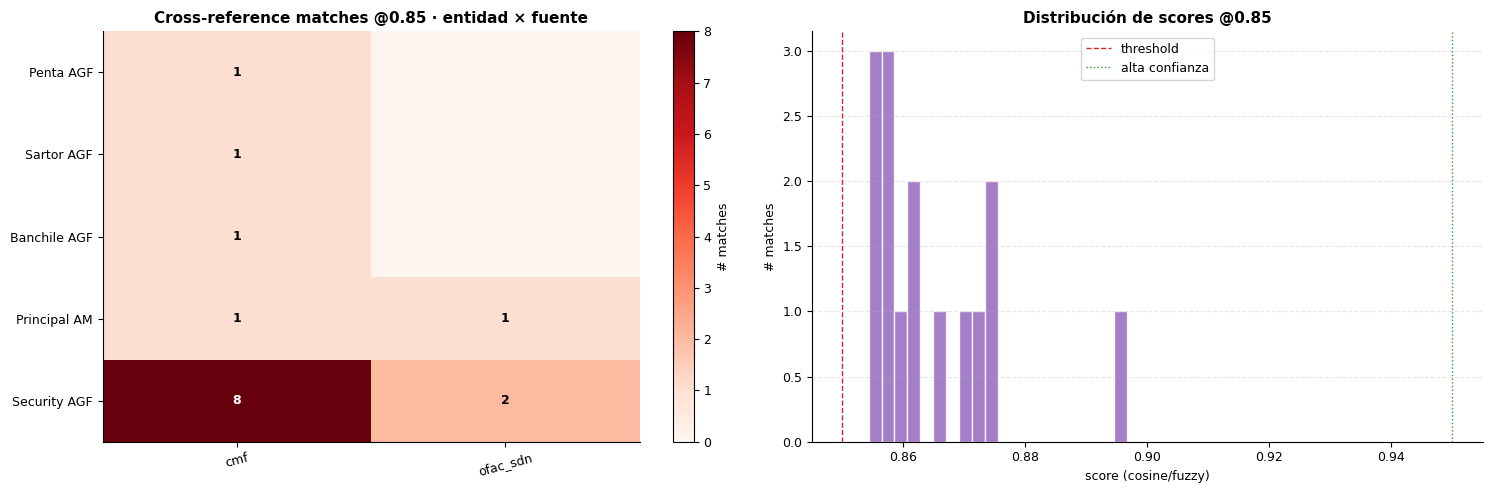

In [24]:
if len(df_xr):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Heatmap entidad x source
    ax = axes[0]
    pivot = df_xr.groupby(["entidad", "source"]).size().unstack(fill_value=0)
    order = df.sort_values(["sector", "hint"])["hint"].tolist()
    pivot = pivot.reindex([h for h in order if h in pivot.index]).fillna(0).astype(int)
    if len(pivot):
        im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=15)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index, fontsize=9)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                v = int(pivot.iloc[i, j])
                if v > 0:
                    ax.text(
                        j,
                        i,
                        str(v),
                        ha="center",
                        va="center",
                        color="white" if v > pivot.values.max() * 0.5 else "black",
                        fontsize=9,
                        fontweight="bold",
                    )
        ax.set_title(f"Cross-reference matches @0.85 · entidad x fuente")
        fig.colorbar(im, ax=ax, label="# matches")

    # Score distribution
    ax = axes[1]
    if len(df_xr["score"].dropna()):
        ax.hist(df_xr["score"], bins=20, color="#9467bd", alpha=0.85, edgecolor="white")
        ax.set_xlabel("score (cosine/fuzzy)")
        ax.set_ylabel("# matches")
        ax.set_title("Distribución de scores @0.85")
        ax.axvline(0.85, color="#d62728", lw=1, ls="--", label="threshold")
        ax.axvline(0.95, color="#2ca02c", lw=1, ls=":", label="alta confianza")
        ax.legend()
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

## 9 · Hechos esenciales · timeline y temas

`recent_material_events` agrega los HE recientes — fusiones, cambios de
propiedad, cancelaciones de fondos, aumentos de capital, designación de gerentes.
Es el canal CMF para anuncios materiales del emisor/AGF.

In [25]:
events_rows = []
for p in profiles:
    for e in p.get("_events", []):
        events_rows.append(
            {
                "entidad": p["hint"],
                "sector": p["sector"],
                "sub_segment": p["sub_segment"],
                "fecha": e.get("publicacion_at"),
                "asunto": e.get("asunto") or "—",
            }
        )
df_ev = pd.DataFrame(events_rows)
if len(df_ev):
    df_ev["fecha"] = pd.to_datetime(df_ev["fecha"], errors="coerce")
    df_ev["año"] = df_ev["fecha"].dt.year

print(f"Total hechos esenciales: {len(df_ev)}")
if len(df_ev):
    print(f"Rango: {df_ev['fecha'].min().date()} → {df_ev['fecha'].max().date()}")
    print(f"\nPor sector:")
    for s, n in df_ev.groupby("sector").size().items():
        print(f"  {SECTOR_LABEL.get(s, s):28s}  {n}")

Total hechos esenciales: 4
Rango: 2026-04-21 → 2026-04-27

Por sector:
  AGF vigente (CMF)             2
  Fintech en CMF                2


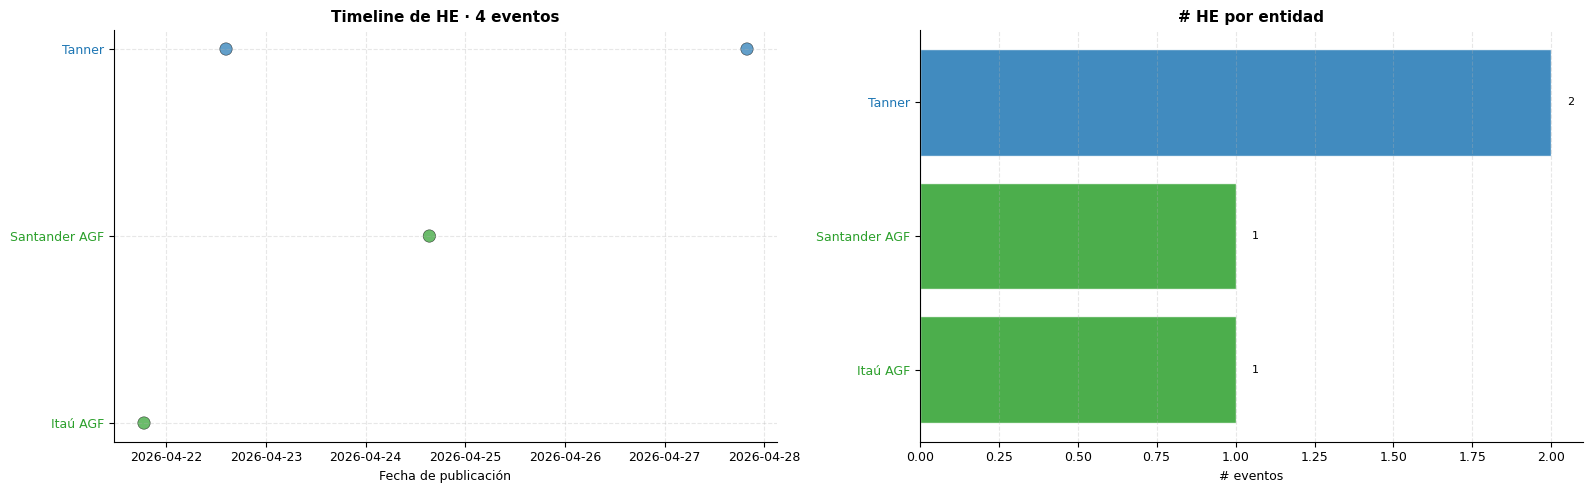

In [26]:
if len(df_ev):
    fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.35 * len(df_ev["entidad"].unique()))))

    # Timeline scatter — fecha x entidad, color por sector
    ax = axes[0]
    bank_y = {b: i for i, b in enumerate(sorted(df_ev["entidad"].unique()))}
    df_ev["y"] = df_ev["entidad"].map(bank_y)
    sec_for_hint = dict(zip(df["hint"], df["sector"], strict=False))
    df_ev["color"] = df_ev["entidad"].map(
        lambda h: SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#999")
    )
    ax.scatter(
        df_ev["fecha"],
        df_ev["y"],
        s=80,
        alpha=0.7,
        c=df_ev["color"],
        edgecolor="black",
        linewidth=0.4,
    )
    ax.set_yticks(list(bank_y.values()))
    ax.set_yticklabels(list(bank_y.keys()), fontsize=9)
    for i, h in enumerate(bank_y.keys()):
        ax.get_yticklabels()[i].set_color(SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#000"))
    ax.set_title(f"Timeline de HE · {len(df_ev)} eventos")
    ax.set_xlabel("Fecha de publicación")
    ax.grid(alpha=0.3, linestyle="--")

    # Bar count per entidad
    ax = axes[1]
    counts = df_ev.groupby("entidad").size().sort_values()
    colors_e = [SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#999") for h in counts.index]
    bars = ax.barh(counts.index, counts.values, color=colors_e, alpha=0.85, edgecolor="white")
    for b, v in zip(bars, counts.values, strict=False):
        ax.text(v + 0.05, b.get_y() + b.get_height() / 2, str(int(v)), va="center", fontsize=8)
    for i, h in enumerate(counts.index):
        ax.get_yticklabels()[i].set_color(SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#000"))
    ax.set_title("# HE por entidad")
    ax.set_xlabel("# eventos")
    ax.grid(axis="x", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

In [27]:
# Análisis de temas en el campo `asunto`
if len(df_ev):
    tokens_he = []
    for txt in df_ev["asunto"]:
        tokens_he.extend(_tokenize_es(str(txt)))
    if tokens_he:
        top_he = Counter(tokens_he).most_common(20)
        words, counts = zip(*top_he, strict=False)
        fig, ax = plt.subplots(figsize=(11, 5))
        ax.barh(
            list(words[::-1]), list(counts[::-1]), color="#bcbd22", alpha=0.85, edgecolor="white"
        )
        for i, c in enumerate(counts[::-1]):
            ax.text(c + 0.05, i, str(c), va="center", fontsize=9)
        ax.set_title(f"Top-20 palabras en asuntos de HE · {len(df_ev)} eventos")
        ax.set_xlabel("# apariciones")
        ax.grid(axis="x", alpha=0.3, linestyle="--")
        plt.tight_layout()
        plt.show()

## 10 · Búsqueda semántica · 8 queries categorizadas

Ejercitamos `search.search` con queries de 4 dominios:
- **Regulación AGF** (Norma de Gestión, NCG 365, valoración cartera)
- **Ley Fintec** (registro RPSF, servicios PSF)
- **Lavado de activos / UAF**
- **Gobierno corporativo / conflicto de interés**

El score es similaridad coseno entre el embedding Voyage de la query y el
embedding del documento.

In [28]:
QUERIES = [
    ("AGF", "Norma de gestión de fondos mutuos NCG 365 valorización"),
    ("AGF", "obligaciones de información a partícipes fondos mutuos"),
    ("Fintec", "Ley 21.521 inscripción registro prestadores servicios financieros"),
    ("Fintec", "asesoría de inversión fintech autorización CMF"),
    ("UAF/AML", "prevención lavado de activos UAF reportes operación sospechosa"),
    ("UAF/AML", "due diligence cliente politicamente expuesto AGF"),
    ("Gov", "conflicto de interés AGF gestor cartera operación relacionada"),
    ("Gov", "gobierno corporativo directores independientes Norma 386"),
]

with CerberusClient() as c:
    rows = []
    for cat, q in QUERIES:
        resp = c.search.search(query=q, top_k=5)
        for h in resp.hits:
            rows.append(
                {
                    "categoria": cat,
                    "query": q[:38] + "…" if len(q) > 38 else q,
                    "score": h.score,
                    "source": h.source_table,
                    "tipo": getattr(h, "tipo_documento", None),
                }
            )

df_search = pd.DataFrame(rows)
print(f"Total hits: {len(df_search)}  ·  queries: {len(QUERIES)}")
print(f"\nPor categoría:")
for cat, n in df_search.groupby("categoria").size().items():
    avg = df_search[df_search["categoria"] == cat]["score"].mean()
    print(f"  {cat:8s}  hits={n:>2}  avg_score={avg:.2f}")

Total hits: 40  ·  queries: 8

Por categoría:
  AGF       hits=10  avg_score=0.41
  Fintec    hits=10  avg_score=0.39
  Gov       hits=10  avg_score=0.35
  UAF/AML   hits=10  avg_score=0.29


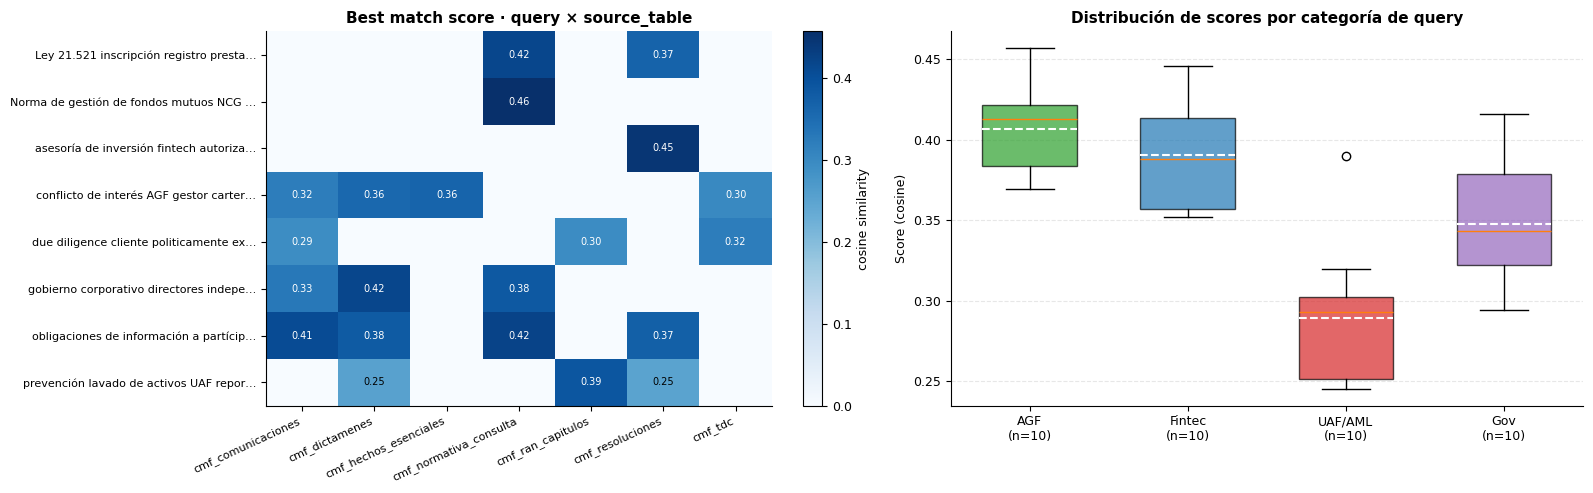

In [29]:
if len(df_search):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Heatmap query x source (best score)
    ax = axes[0]
    heat = df_search.groupby(["query", "source"])["score"].max().unstack(fill_value=0)
    if len(heat):
        im = ax.imshow(
            heat.values, cmap="Blues", aspect="auto", vmin=0, vmax=heat.values.max() or 1
        )
        ax.set_xticks(range(len(heat.columns)))
        ax.set_xticklabels(heat.columns, rotation=25, ha="right", fontsize=8)
        ax.set_yticks(range(len(heat.index)))
        ax.set_yticklabels(heat.index, fontsize=8)
        for i in range(len(heat.index)):
            for j in range(len(heat.columns)):
                v = heat.iloc[i, j]
                if v > 0:
                    ax.text(
                        j,
                        i,
                        f"{v:.2f}",
                        ha="center",
                        va="center",
                        color="white" if v > heat.values.max() * 0.6 else "black",
                        fontsize=7,
                    )
        ax.set_title("Best match score · query x source_table")
        fig.colorbar(im, ax=ax, label="cosine similarity")

    # Score distribution per category
    ax = axes[1]
    cat_palette = {"AGF": "#2ca02c", "Fintec": "#1f77b4", "UAF/AML": "#d62728", "Gov": "#9467bd"}
    data, labels, positions, colors_c = [], [], [], []
    for i, cat in enumerate(["AGF", "Fintec", "UAF/AML", "Gov"]):
        vals = df_search[df_search["categoria"] == cat]["score"].dropna().tolist()
        if vals:
            data.append(vals)
            labels.append(f"{cat}\n(n={len(vals)})")
            positions.append(i)
            colors_c.append(cat_palette[cat])
    if data:
        bp = ax.boxplot(
            data,
            positions=positions,
            widths=0.6,
            patch_artist=True,
            showmeans=True,
            meanline=True,
            meanprops={"color": "white", "linewidth": 1.5},
        )
        for patch, c in zip(bp["boxes"], colors_c, strict=False):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels)
        ax.set_ylabel("Score (cosine)")
        ax.set_title("Distribución de scores por categoría de query")
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

## 11 · Telón macro · UF · USD · TPM · IPC (12m)

AGFs y fintechs comparten la misma macro chilena: TPM define costo de capital,
UF es activo refugio retail, USD el tipo de cambio, IPC la presión inflacionaria.

Puntos por serie:
  UF      366 puntos
  USD     248 puntos
  TPM     248 puntos
  IPC      10 puntos


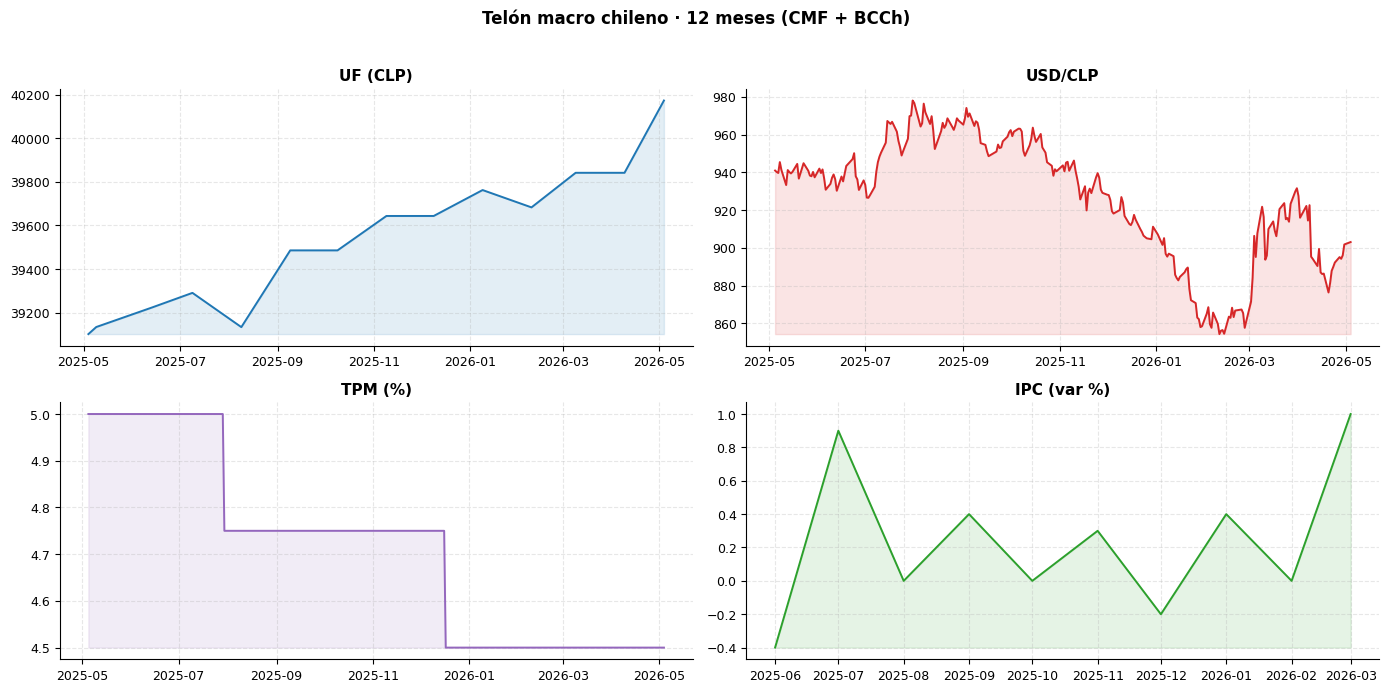

In [30]:
today = date.today()
start = (today - timedelta(days=365)).isoformat()
end = today.isoformat()

with CerberusClient() as c:
    series = {
        "UF": c.indicadores.history("UF", from_=start, to=end),
        "USD": c.indicadores.history("USD", from_=start, to=end),
        "TPM": c.indicadores.history("TPM", from_=start, to=end),
        "IPC": c.indicadores.history("IPC", from_=start, to=end),
    }
print("Puntos por serie:")
for k, v in series.items():
    print(f"  {k:5s}  {len(v):>4} puntos")


def _df_(s):
    if not s:
        return pd.DataFrame(columns=["date", "value"])
    return pd.DataFrame(s).assign(
        date=lambda d: pd.to_datetime(d["date"]), value=lambda d: pd.to_numeric(d["value"])
    )


df_uf, df_usd, df_tpm, df_ipc = (
    _df_(series["UF"]),
    _df_(series["USD"]),
    _df_(series["TPM"]),
    _df_(series["IPC"]),
)

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
fig.suptitle("Telón macro chileno · 12 meses (CMF + BCCh)", fontsize=12, weight="bold")
for ax, (df_, lbl, color) in zip(
    axes.flat,
    [
        (df_uf, "UF (CLP)", "#1f77b4"),
        (df_usd, "USD/CLP", "#d62728"),
        (df_tpm, "TPM (%)", "#9467bd"),
        (df_ipc, "IPC (var %)", "#2ca02c"),
    ],
    strict=False,
):
    if len(df_):
        ax.plot(df_["date"], df_["value"], color=color, lw=1.4)
        ax.fill_between(df_["date"], df_["value"].min(), df_["value"], alpha=0.12, color=color)
        ax.set_title(lbl)
        ax.grid(alpha=0.3, linestyle="--")
    else:
        ax.text(0.5, 0.5, f"{lbl}\n(sin datos)", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 12 · Registro RPSF · Ley Fintec 21.521 · zona gris cuantificada

El **Registro de Prestadores de Servicios Financieros (RPSF)** es el registro
creado por la Ley 21.521 (Feb 2024) para fintechs que ofrecen servicios
específicos: asesoría de inversión, asesoría crediticia, custodia, intermediación,
ruteo de órdenes, financiamiento colectivo, sistemas alternativos de transacción.

`rpsf.iter_all` y `rpsf.by_entity(eid)` permiten cruzar el universo CMF clásico
con el de Ley Fintec — el bridge regulatorio.

In [31]:
# Inventario completo RPSF
with CerberusClient() as c:
    rpsf_all = list(c.rpsf.iter_all())
print(f"Total inscripciones RPSF: {len(rpsf_all)}")

df_rpsf = pd.DataFrame(rpsf_all)
if len(df_rpsf):
    df_rpsf["fecha_inscripcion"] = pd.to_datetime(df_rpsf["fecha_inscripcion"], errors="coerce")
    df_rpsf["fecha_cancelacion"] = pd.to_datetime(df_rpsf["fecha_cancelacion"], errors="coerce")
    print(f"\nPor servicio:")
    print(df_rpsf["servicio"].value_counts().to_string())
    print(f"\nActivas: {df_rpsf['is_active'].sum()}/{len(df_rpsf)}")

Total inscripciones RPSF: 235

Por servicio:
servicio
asesoria_inversion                         210
enrutamiento_ordenes                         9
asesoria_crediticia                          5
custodia_instrumentos_financieros            5
sistema_alternativo_transaccion              5
intermediacion_instrumentos_financieros      1

Activas: 235/235


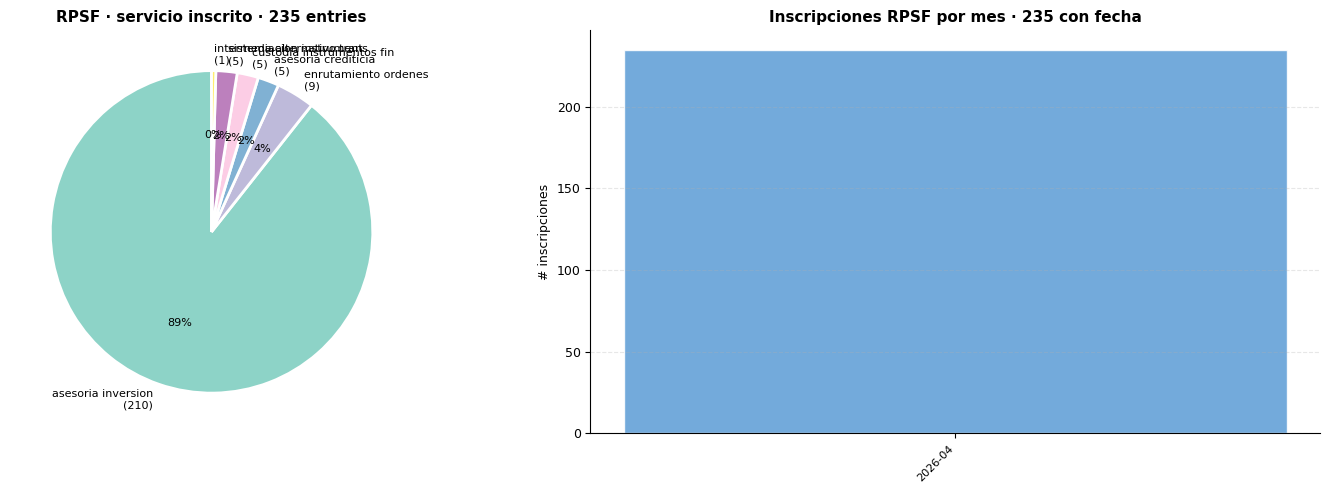

In [32]:
if len(df_rpsf):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Pie servicios
    ax = axes[0]
    serv_counts = df_rpsf["servicio"].value_counts()
    colors_p = plt.cm.Set3(np.linspace(0, 1, len(serv_counts)))
    ax.pie(
        serv_counts.values,
        labels=[f"{s.replace('_', ' ')[:25]}\n({n})" for s, n in serv_counts.items()],
        colors=colors_p,
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
        textprops={"fontsize": 8},
    )
    ax.set_title(f"RPSF · servicio inscrito · {len(df_rpsf)} entries")

    # Bar: inscripciones por mes
    ax = axes[1]
    df_month = df_rpsf.dropna(subset=["fecha_inscripcion"]).copy()
    if len(df_month):
        df_month["mes"] = df_month["fecha_inscripcion"].dt.to_period("M").astype(str)
        m_counts = df_month["mes"].value_counts().sort_index()
        ax.bar(
            range(len(m_counts)), m_counts.values, color="#5b9bd5", alpha=0.85, edgecolor="white"
        )
        ax.set_xticks(range(len(m_counts)))
        ax.set_xticklabels(m_counts.index, rotation=45, ha="right", fontsize=8)
        ax.set_title(f"Inscripciones RPSF por mes · {len(df_month)} con fecha")
        ax.set_ylabel("# inscripciones")
        ax.grid(axis="y", alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

### Cruce portafolio · ¿quién está en RPSF?

Para cada entidad del portafolio CMF + las zona-gris resueltas a entity_id,
chequeamos si tiene inscripción RPSF activa. Esto cuantifica el **bridge** entre
los dos regímenes.

In [33]:
async def fetch_rpsf(c, eid):
    if not eid:
        return []
    try:
        return await c.rpsf.by_entity(eid)
    except Exception:
        return []


async def fetch_rpsf_all():
    sem = asyncio.Semaphore(5)

    async def one(o):
        async with sem, AsyncCerberusClient() as c:
            return o["hint"], o["sector"], await fetch_rpsf(c, o["entity_id"])

    return await asyncio.gather(*(one(o) for o in ownerships))


rpsf_per_entity = asyncio.run(fetch_rpsf_all())
rpsf_rows = []
for hint, sector, entries in rpsf_per_entity:
    for e in entries:
        rpsf_rows.append(
            {
                "entidad": hint,
                "sector": sector,
                "servicio": e.get("servicio"),
                "is_active": e.get("is_active"),
                "fecha_inscripcion": e.get("fecha_inscripcion"),
            }
        )
df_rpsf_pf = pd.DataFrame(rpsf_rows)
print(f"Inscripciones RPSF para entidades del portafolio CMF: {len(df_rpsf_pf)}")
if len(df_rpsf_pf):
    print(df_rpsf_pf.to_string(index=False))
else:
    print("→ Ninguna entidad del portafolio CMF clásico aparece en RPSF.")
    print("  Esto refuerza la tesis: las AGFs viven en el régimen CMF clásico,")
    print("  NO necesitan inscribirse en RPSF (Ley Fintec).")

Inscripciones RPSF para entidades del portafolio CMF: 0
→ Ninguna entidad del portafolio CMF clásico aparece en RPSF.
  Esto refuerza la tesis: las AGFs viven en el régimen CMF clásico,
  NO necesitan inscribirse en RPSF (Ley Fintec).


### Resolver fintechs zona gris y chequear RPSF

Tomamos los 17 nombres del set FINTECHS_OUT y para cada uno:
1. `resolve.resolve(query=name)` — ¿está en el universo de entidades?
2. Si está, `rpsf.by_entity(entity_id)` — ¿está inscrita bajo Ley Fintec?

Las que aparezcan en (1) pero no (2) son **fintechs en CMF sin inscripción Fintec**.
Las que aparezcan en (1) y (2) son **bridge cases** (existen en ambos registros).
Las que NO aparezcan en (1) son **completamente zona gris** (no en CMF, no en RPSF).

In [34]:
async def fetch_resolve_rpsf(c, item):
    name, sub = item
    try:
        r = await c.resolve.resolve(query=name)
        result = {
            "name": name,
            "sub": sub,
            "kind": r.get("kind"),
            "entity_id": r.get("entity_id"),
            "conf": r.get("confidence"),
            "method": r.get("method"),
        }
        if r.get("kind") == "entity" and r.get("entity_id"):
            try:
                rpsf_entries = await c.rpsf.by_entity(r["entity_id"])
                result["rpsf_count"] = len(rpsf_entries)
                result["rpsf_servicios"] = "; ".join({e.get("servicio") for e in rpsf_entries})
                # Try to fetch entity to get rut + legal_name
                try:
                    ent = await c.entities.get(r["entity_id"])
                    result["rut"] = ent.get("rut") or "—"
                    result["legal_name"] = (ent.get("legal_name") or "")[:55]
                except Exception:
                    pass
            except Exception:
                result["rpsf_count"] = 0
                result["rpsf_servicios"] = ""
        else:
            result["rpsf_count"] = 0
            result["rpsf_servicios"] = ""
        return result
    except Exception as e:
        return {
            "name": name,
            "sub": sub,
            "kind": "err",
            "err": str(e)[:80],
            "rpsf_count": 0,
            "rpsf_servicios": "",
        }


fintech_resolved = asyncio.run(gather_throttled(fetch_resolve_rpsf, FINTECHS_OUT, concurrency=5))
df_gap = pd.DataFrame(fintech_resolved)
df_gap["en_cmf"] = df_gap["kind"] == "entity"
df_gap["en_rpsf"] = df_gap["rpsf_count"].fillna(0).astype(int) > 0

n_total = len(df_gap)
n_cmf = df_gap["en_cmf"].sum()
n_rpsf = df_gap["en_rpsf"].sum()
n_both = (df_gap["en_cmf"] & df_gap["en_rpsf"]).sum()
n_neither = ((~df_gap["en_cmf"]) & (~df_gap["en_rpsf"])).sum()

print(f"Fintechs probadas: {n_total}")
print(f"  En CMF (entidad resuelta):   {n_cmf}/{n_total}")
print(f"  En RPSF (Ley Fintec):        {n_rpsf}/{n_total}")
print(f"  En ambos (bridge cases):     {n_both}/{n_total}")
print(f"  En ninguno (zona gris pura): {n_neither}/{n_total}")
print()
print(df_gap[["name", "sub", "en_cmf", "en_rpsf", "rpsf_servicios"]].to_string(index=False))

Fintechs probadas: 17
  En CMF (entidad resuelta):   4/17
  En RPSF (Ley Fintec):        3/17
  En ambos (bridge cases):     3/17
  En ninguno (zona gris pura): 13/17

                   name                        sub  en_cmf  en_rpsf                           rpsf_servicios
     MERCADO PAGO CHILE             wallet · pagos   False    False                                         
       MACH (BCI Pagos)                     wallet   False    False                                         
                  KHIPU              pagos · botón   False    False                                         
       CUMPLO CHILE SPA    p2p lending · factoring   False    False                                         
               BUDA.COM            exchange crypto   False    False                                         
            XEPELIN SPA          factoring digital   False    False                                         
             TOKU PAGOS          pagos recurrentes   False    False  

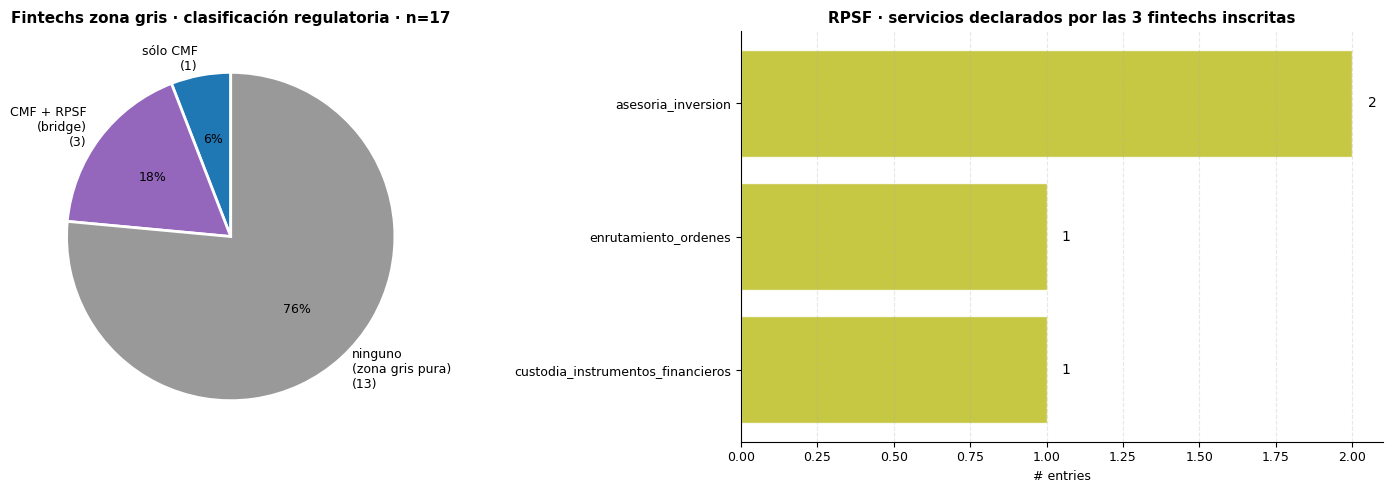

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Venn-style chart (manual via overlapping pies)
ax = axes[0]
labels = ["sólo CMF", "CMF + RPSF\n(bridge)", "sólo RPSF", "ninguno\n(zona gris pura)"]
sizes = [
    int((df_gap["en_cmf"] & ~df_gap["en_rpsf"]).sum()),
    int(n_both),
    int((df_gap["en_rpsf"] & ~df_gap["en_cmf"]).sum()),
    int(n_neither),
]
colors_v = ["#1f77b4", "#9467bd", "#ff7f0e", "#999999"]
nonzero = [(lbl, s, c) for lbl, s, c in zip(labels, sizes, colors_v, strict=False) if s > 0]
if nonzero:
    ls, ss, cs = zip(*nonzero, strict=False)
    ax.pie(
        ss,
        labels=[f"{lbl}\n({s})" for lbl, s in zip(ls, ss, strict=False)],
        colors=cs,
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2},
    )
ax.set_title(f"Fintechs zona gris · clasificación regulatoria · n={n_total}")

# Bar of services declared in RPSF (for those that did register)
ax = axes[1]
servs = []
for s in df_gap["rpsf_servicios"]:
    if s:
        servs.extend([x.strip() for x in s.split(";") if x.strip()])
if servs:
    sv = pd.Series(servs).value_counts()
    ax.barh(sv.index, sv.values, color="#bcbd22", alpha=0.85, edgecolor="white")
    for i, v in enumerate(sv.values):
        ax.text(v + 0.05, i, str(v), va="center", fontsize=10)
    ax.set_title(f"RPSF · servicios declarados por las {n_rpsf} fintechs inscritas")
    ax.set_xlabel("# entries")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3, linestyle="--")
else:
    ax.text(
        0.5,
        0.5,
        "Ninguna fintech del set\nestá inscrita en RPSF",
        ha="center",
        va="center",
        transform=ax.transAxes,
        fontsize=12,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

## 13 · Caso Fintual · doble sombrero AGF + fintech

Fintual opera **simultáneamente** en tres entidades:
- **Fintual AGF** (CMF, RUT 76.810.627-4) — fondos mutuos
- **Fintual Crowd SpA** (CMF, RUT 76.086.428-5) — crowdfunding
- **Fintual SpA** (la app consumer) — robo-advisor (fuera CMF clásico)

Es el único bridge confirmado entre los dos rubros. Comparamos lado a lado.

In [36]:
fintual_ruts = ["76810627-4", "76086428-5"]
fintual_rows = df[df["rut"].isin(fintual_ruts)].copy()
print("Comparativo Fintual AGF vs Fintual Crowd:\n")
print(
    fintual_rows[
        ["hint", "legal_name", "sector", "status", "risk_score", "n_directors", "lei", "age_years"]
    ].to_string(index=False)
)

fintual_sancs = (
    df_sanc[df_sanc["entidad"].isin(fintual_rows["hint"])] if len(df_sanc) else pd.DataFrame()
)
print(f"\nSanciones registradas Fintual: {len(fintual_sancs)}")
if len(fintual_sancs):
    print(fintual_sancs[["entidad", "fecha", "estado", "infraccion"]].to_string(index=False))

fintual_xref = df_xr[df_xr["entidad"].isin(fintual_rows["hint"])] if len(df_xr) else pd.DataFrame()
print(f"\nCross-reference matches @0.85: {len(fintual_xref)}")
if len(fintual_xref):
    print(fintual_xref[["entidad", "source", "matched_name", "score"]].to_string(index=False))

# Fintual hechos esenciales
fintual_events = []
for p in profiles:
    if p["rut"] in fintual_ruts:
        for e in p["_events"]:
            fintual_events.append(
                {"entidad": p["hint"], "fecha": e.get("publicacion_at"), "asunto": e.get("asunto")}
            )
df_fev = pd.DataFrame(fintual_events)
if len(df_fev):
    df_fev["fecha"] = pd.to_datetime(df_fev["fecha"], errors="coerce")
    print(f"\nHechos esenciales recientes Fintual ({len(df_fev)}):")
    print(df_fev.sort_values("fecha", ascending=False).head(8).to_string(index=False))

Comparativo Fintual AGF vs Fintual Crowd:

         hint                                    legal_name      sector  status  risk_score  n_directors                  lei  age_years
  Fintual AGF FINTUAL ADMINISTRADORA GENERAL DE FONDOS S.A. agf_vigente vigente           0            0 2549004RUEQB0XKNTI34        NaN
Fintual Crowd                             Fintual Crowd SpA  fintech_in vigente           5            0                  NaN        5.2

Sanciones registradas Fintual: 0

Cross-reference matches @0.85: 0


## 14 · Caso Tenpo · journey wallet → banco digital

**Tenpo** entró al universo CMF al transformarse en banco. El campo
`legal_name = "TENPO BANK CHILE"` (no "Tenpo SpA") es la firma del paso
del régimen Ley Fintec/no-supervisado al régimen banking-supervised.

In [37]:
tenpo_row = df[df["hint"] == "Tenpo Bank"]
if len(tenpo_row):
    r = tenpo_row.iloc[0]
    print(f"Tenpo Bank Chile · KYB profile:")
    print(f"  legal_name:        {r['legal_name']}")
    print(f"  status:            {r['status']}")
    print(f"  risk_score:        {r['risk_score']}")
    print(f"  inscription_date:  {r['inscription_date']}")
    print(f"  age_years:         {r['age_years']}")
    print(f"  LEI:               {r['entity_lei']}")
    print(f"  parent_group:      {r['parent_group']}")
    print(f"  n_directors:       {r['n_directors']}")
    print(f"  n_recent_events:   {r['n_recent_events']}")

    tenpo_events = next((p["_events"] for p in profiles if p["hint"] == "Tenpo Bank"), [])
    if tenpo_events:
        print(f"\nHE recientes ({len(tenpo_events)}):")
        for e in tenpo_events[:6]:
            print(f"  {e.get('publicacion_at')[:10]}  {e.get('asunto')[:80]}")

Tenpo Bank Chile · KYB profile:
  legal_name:        TENPO BANK CHILE
  status:            vigente
  risk_score:        0
  inscription_date:  NaT
  age_years:         nan
  LEI:               9845003O37R79479FD63
  parent_group:      Krealo / Credicorp
  n_directors:       0
  n_recent_events:   0


## 15 · Bank-affiliated vs boutique vs global · perfil agregado

Tres familias dentro de las AGFs vigentes. ¿Difieren sus perfiles de riesgo,
sanciones, edad y LEI?

In [38]:
agf_v = df[df["sector"] == "agf_vigente"]
agg_sub = (
    agf_v.groupby("sub_segment")
    .agg(
        n=("hint", "count"),
        avg_risk=("risk_score", "mean"),
        avg_age=("age_years", "mean"),
        pct_lei=("has_lei", lambda s: s.mean() * 100),
    )
    .round(1)
)

# Sanctions per sub_segment
if len(df_sanc):
    sanc_sub = df_sanc[df_sanc["sector"] == "agf_vigente"].groupby("sub_segment").size()
    agg_sub["sanciones_total"] = sanc_sub.reindex(agg_sub.index).fillna(0).astype(int)
    agg_sub["sanciones_por_entidad"] = (agg_sub["sanciones_total"] / agg_sub["n"]).round(1)
print(agg_sub)

                   n  avg_risk  avg_age  pct_lei
sub_segment                                     
bank-affiliated    6       0.0      NaN    100.0
boutique           7       0.0      NaN    100.0
fintech-disrupted  1       0.0      NaN    100.0
global-affiliated  1       0.0      NaN    100.0


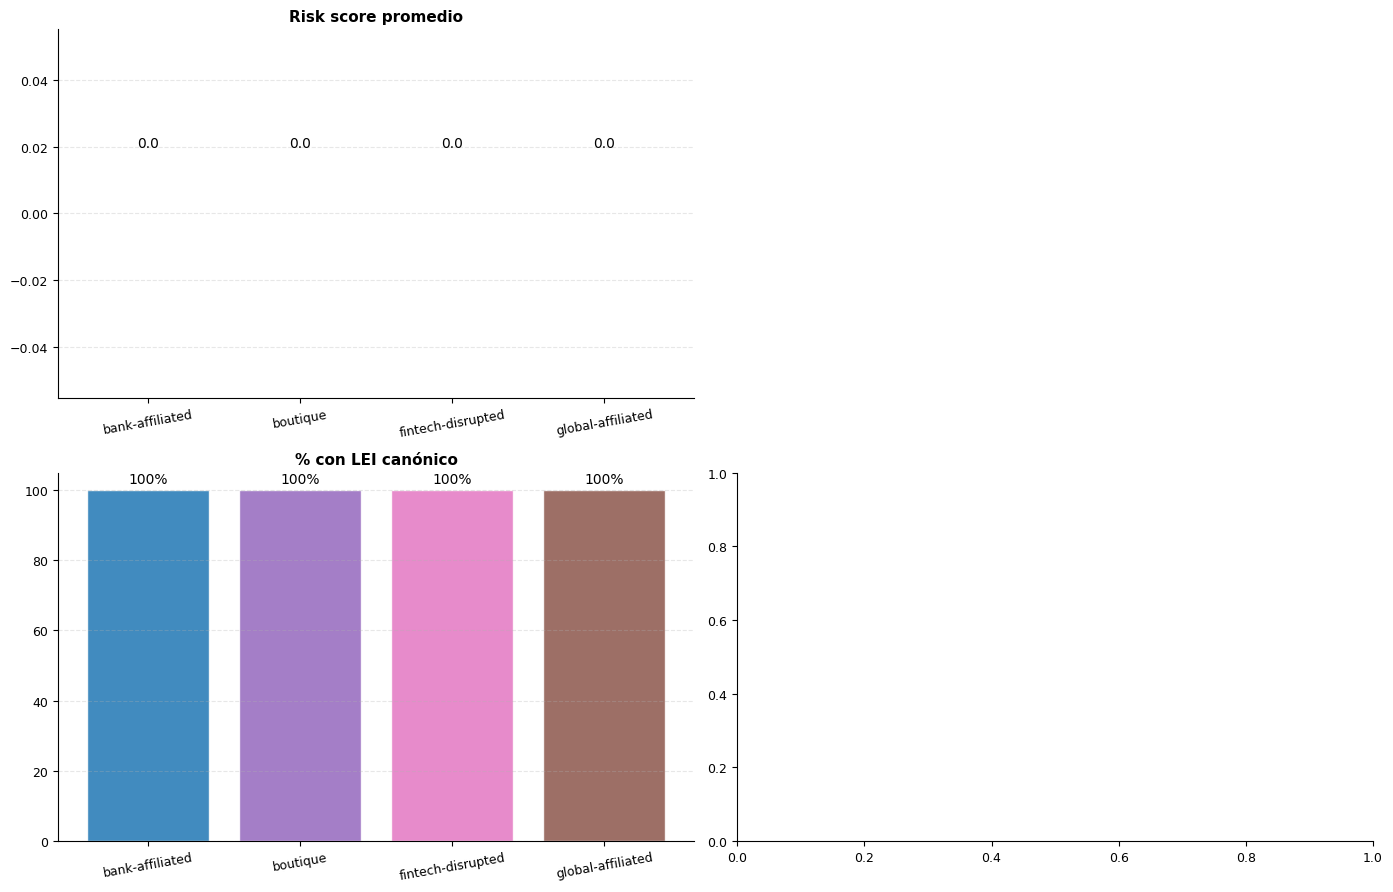

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

metrics = [
    ("avg_risk", "Risk score promedio", axes[0, 0], "{:.1f}"),
    ("avg_age", "Antigüedad promedio (años)", axes[0, 1], "{:.1f}"),
    ("pct_lei", "% con LEI canónico", axes[1, 0], "{:.0f}%"),
    ("sanciones_por_entidad", "Sanciones promedio por entidad", axes[1, 1], "{:.1f}"),
]
for col, title, ax, fmt in metrics:
    if col not in agg_sub.columns:
        continue
    vals = agg_sub[col].dropna()
    if not len(vals):
        ax.axis("off")
        continue
    xs = list(range(len(vals)))
    colors_x = [SUB_SEGMENT_COLORS.get(s, "#999") for s in vals.index]
    bars = ax.bar(xs, vals.values, color=colors_x, alpha=0.85, edgecolor="white")
    for i, v in enumerate(vals.values):
        ax.text(i, v + (vals.max() or 1) * 0.02, fmt.format(v), ha="center", fontsize=10)
    ax.set_xticks(xs)
    ax.set_xticklabels(vals.index, rotation=10)
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## 16 · Vigentes vs legacy · qué cambia al perder la vigencia

Comparamos el conjunto AGFs vigentes vs AGFs no_vigentes en métricas clave.

              n  avg_risk  avg_age  pct_lei
sector                                     
agf_legacy    5      35.0      NaN      0.0
agf_vigente  15       0.0      NaN    100.0


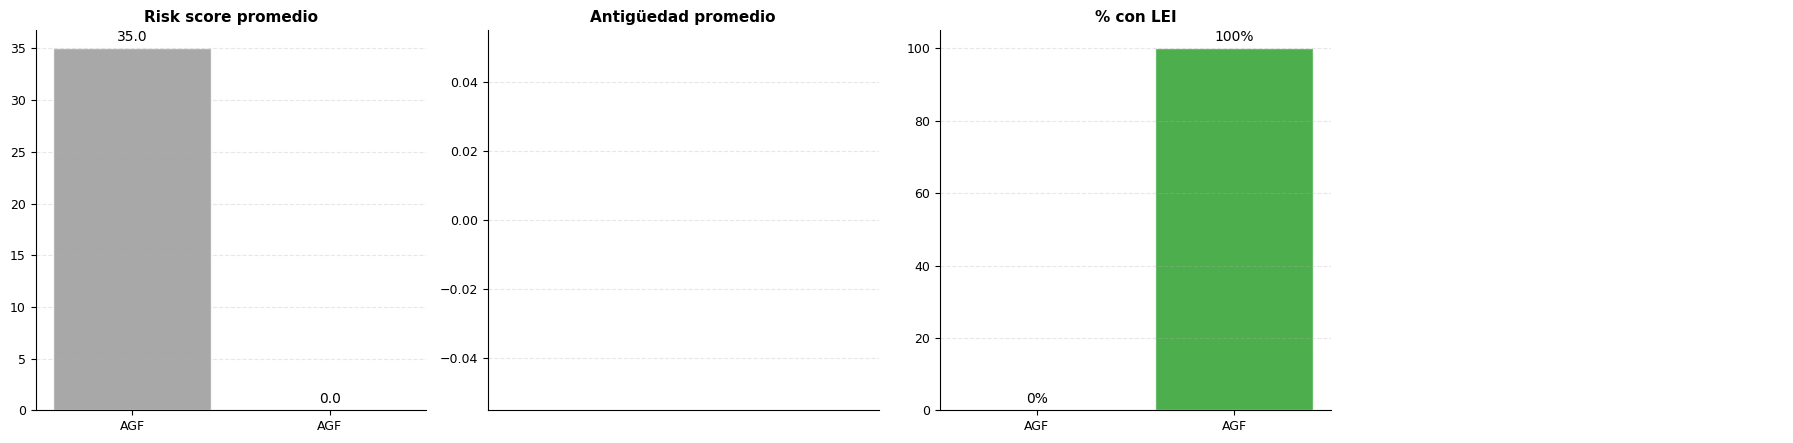

In [40]:
agg_status = (
    df[df["sector"].isin(["agf_vigente", "agf_legacy"])]
    .groupby("sector")
    .agg(
        n=("hint", "count"),
        avg_risk=("risk_score", "mean"),
        avg_age=("age_years", "mean"),
        pct_lei=("has_lei", lambda s: s.mean() * 100),
    )
    .round(1)
)

if len(df_sanc):
    sanc_by_sector = df_sanc.groupby("sector").size()
    agg_status["n_sanciones"] = sanc_by_sector.reindex(agg_status.index).fillna(0).astype(int)
    agg_status["sanciones_por_entidad"] = (agg_status["n_sanciones"] / agg_status["n"]).round(2)

print(agg_status)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
metrics = [
    ("avg_risk", "Risk score promedio", "{:.1f}"),
    ("avg_age", "Antigüedad promedio", "{:.1f}a"),
    ("pct_lei", "% con LEI", "{:.0f}%"),
    ("sanciones_por_entidad", "Sanciones / entidad", "{:.1f}"),
]
for ax, (col, title, fmt) in zip(axes.flat, metrics, strict=False):
    if col not in agg_status.columns:
        ax.axis("off")
        continue
    vals = agg_status[col].dropna()
    xs = list(range(len(vals)))
    colors_x = [SECTOR_COLORS[s] for s in vals.index]
    ax.bar(xs, vals.values, color=colors_x, alpha=0.85, edgecolor="white")
    for i, v in enumerate(vals.values):
        ax.text(i, v + (vals.max() or 1) * 0.02, fmt.format(v), ha="center", fontsize=10)
    ax.set_xticks(xs)
    ax.set_xticklabels([SECTOR_LABEL[s].split()[0] for s in vals.index])
    ax.set_title(title)
    ax.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

## 17 · Correlaciones macro · ¿qué predice qué?

Construimos una matriz de correlación entre risk_score, antigüedad, # directores,
# sanciones, # HE, presencia de LEI. Esto revela las dinámicas implícitas:
¿la antigüedad correlaciona con menos sanciones? ¿La presencia de LEI con
risk_score más bajo?

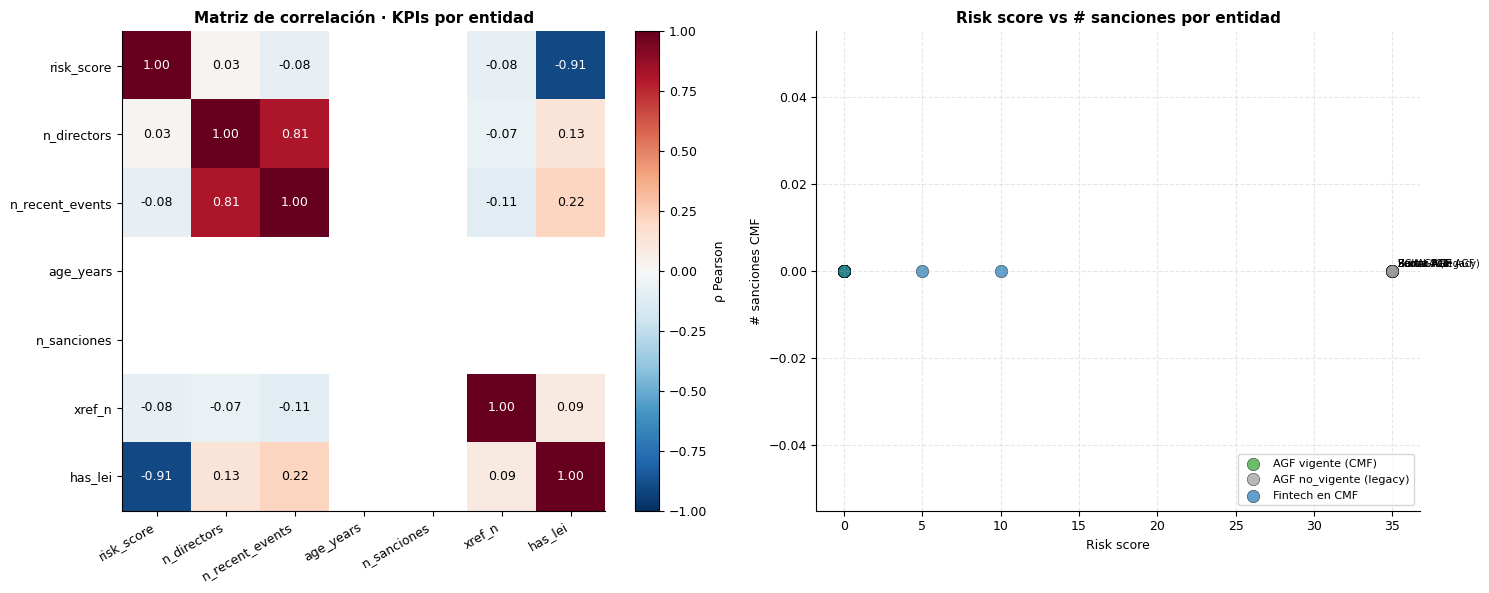

In [41]:
master = df.set_index("hint")[
    ["sector", "sub_segment", "risk_score", "n_directors", "n_recent_events", "age_years"]
].copy()
master["n_sanciones"] = (
    df_sanc.groupby("entidad").size().reindex(master.index).fillna(0).astype(int)
    if len(df_sanc)
    else 0
)
master["xref_n"] = (
    df_xr.groupby("entidad").size().reindex(master.index).fillna(0).astype(int) if len(df_xr) else 0
)
master["has_lei"] = df.set_index("hint")["has_lei"].astype(int)
master = master.sort_values(["sector", "risk_score"], na_position="last")

# Numerical correlation matrix
num_cols = [
    "risk_score",
    "n_directors",
    "n_recent_events",
    "age_years",
    "n_sanciones",
    "xref_n",
    "has_lei",
]
corr = master[num_cols].corr(numeric_only=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Heatmap correlación
ax = axes[0]
im = ax.imshow(corr.values, cmap="RdBu_r", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=30, ha="right", fontsize=9)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=9)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        v = corr.iloc[i, j]
        if pd.notna(v):
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                color="white" if abs(v) > 0.5 else "black",
                fontsize=9,
            )
ax.set_title("Matriz de correlación · KPIs por entidad")
fig.colorbar(im, ax=ax, label="r Pearson")

# Scatter risk vs sanciones
ax = axes[1]
sec_for_hint = dict(zip(df["hint"], df["sector"], strict=False))
for sec in ["agf_vigente", "agf_legacy", "fintech_in"]:
    sub = master[master["sector"] == sec]
    if len(sub):
        ax.scatter(
            sub["risk_score"],
            sub["n_sanciones"],
            s=80,
            color=SECTOR_COLORS[sec],
            alpha=0.7,
            edgecolor="black",
            linewidth=0.4,
            label=SECTOR_LABEL[sec],
        )
        for h, row in sub.iterrows():
            if row["n_sanciones"] >= 3 or (row["risk_score"] and row["risk_score"] >= 30):
                ax.annotate(
                    h[:18],
                    (row["risk_score"], row["n_sanciones"]),
                    fontsize=7,
                    xytext=(4, 3),
                    textcoords="offset points",
                )
ax.set_xlabel("Risk score")
ax.set_ylabel("# sanciones CMF")
ax.set_title("Risk score vs # sanciones por entidad")
ax.legend(loc="lower right", fontsize=8)
ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

## 18 · Matriz de cobertura · entidad × dimensión

Permite ver en una sola lámina qué endpoint pobló qué entidad. Filas
coloreadas por sector, columnas son las 11 dimensiones que el SDK explora.

In [42]:
coverage = []
for rut, hint, sector, sub, parent in PORTFOLIO:
    profile = next(p for p in profiles if p["rut"] == rut)
    o = next(x for x in ownerships if x["rut"] == rut)
    bs = next(b for b in bank_sancs if b["rut"] == rut)
    rpsf_n = next((len(e[2]) for e in rpsf_per_entity if e[0] == hint), 0)

    has_lei_own = bool(
        o.get("ownership", {}).get("subject_lei") if isinstance(o.get("ownership"), dict) else False
    )
    coverage.append(
        {
            "entidad": hint,
            "sector": sector,
            "kyb": "✓" if not profile.get("_kyb_err") else "—",
            "directors": "✓" if profile["n_directors"] > 0 else "—",
            "lei (canon)": "✓" if o.get("entity_lei") else "—",
            "ownership": "✓" if has_lei_own else "—",
            "inscripción": "✓" if profile["inscription_date"] else "—",
            "cancellation": "✓" if profile["cancellation_date"] else "—",
            "sanciones": str(len(bs.get("sanctions", []))) if bs.get("sanctions") else "0",
            "hechos_es": str(profile["n_recent_events"]) if profile["n_recent_events"] else "0",
            "xref": str(int(df_xr[df_xr["entidad"] == hint].shape[0])) if len(df_xr) else "0",
            "rpsf": str(rpsf_n) if rpsf_n else "—",
        }
    )
df_cov = pd.DataFrame(coverage).set_index("entidad")
df_cov

,sector,kyb,directors,lei (canon),ownership,inscripción,cancellation,sanciones,hechos_es,xref,rpsf
entidad,,,,,,,,,,,
Banchile AGF,agf_vigente,✓,—,✓,✓,—,—,0,0,1,—
BTG Pactual AGF,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—
BCI AssetMgmt,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—
Bice AGF,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—
Vinci Compass,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—
Principal AM,agf_vigente,✓,—,✓,✓,—,—,0,0,2,—
Fintual AGF,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—
Moneda AGF,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—
Falcom AGF,agf_vigente,✓,—,✓,✓,—,—,0,0,0,—


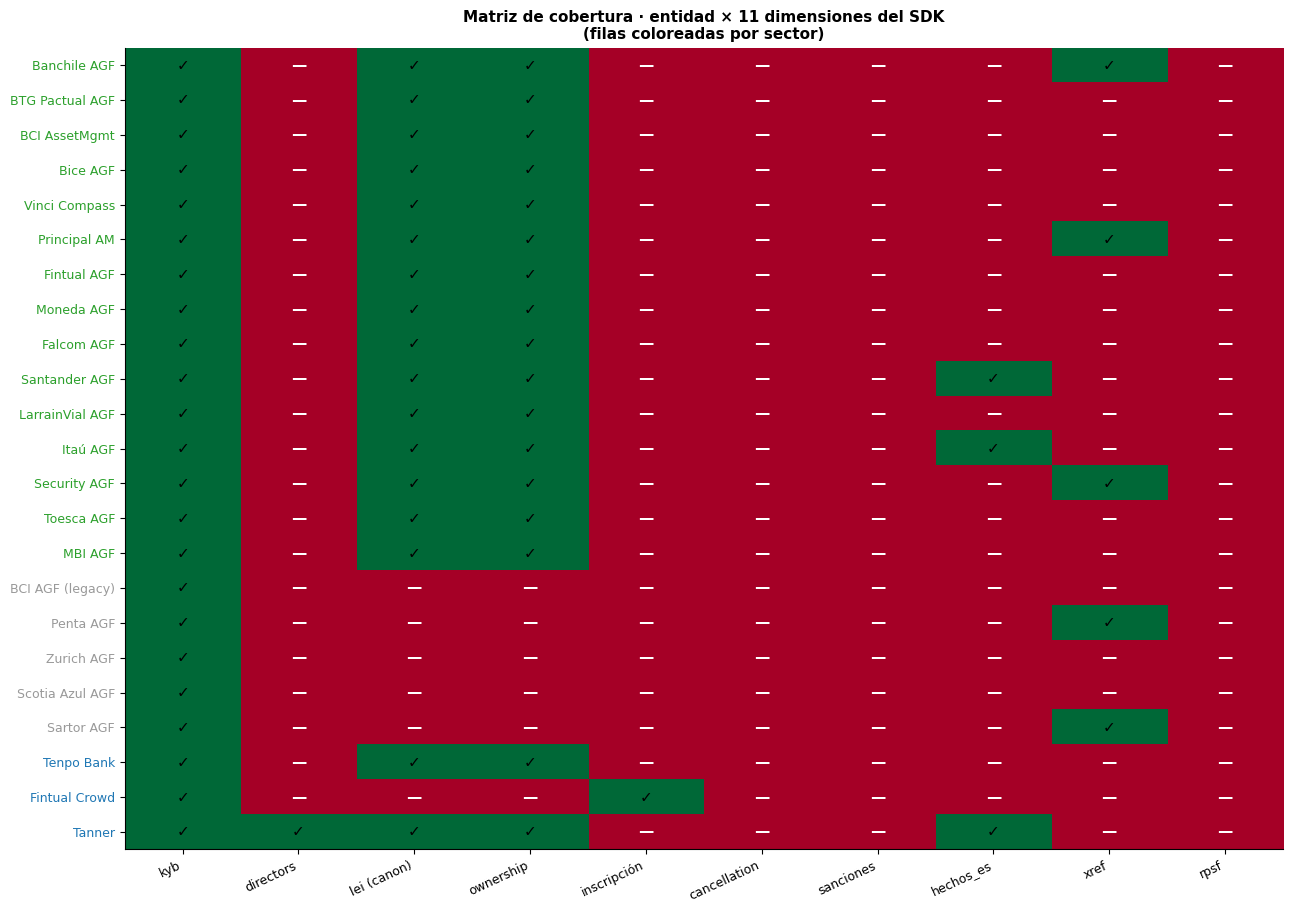


Cobertura por dimensión (% sobre 23 entidades):
  kyb                   100%  (23/23)
  directors               4%  (1/23)
  lei (canon)            74%  (17/23)
  ownership              74%  (17/23)
  inscripción             4%  (1/23)
  cancellation            0%  (0/23)
  sanciones               0%  (0/23)
  hechos_es              13%  (3/23)
  xref                   22%  (5/23)
  rpsf                    0%  (0/23)

Cobertura comparativa por sector:
  AGF vigente (CMF)              33.3%  (entidades=15)
  AGF no_vigente (legacy)        14.0%  (entidades=5)
  Fintech en CMF                 33.3%  (entidades=3)


In [43]:
def _to_bin(v):
    if v == "✓":
        return 1
    if v == "—":
        return 0
    try:
        return 1 if int(v) > 0 else 0
    except (ValueError, TypeError):
        return 0


bin_df = df_cov.drop(columns=["sector"]).map(_to_bin).astype(int)

fig, ax = plt.subplots(figsize=(13, max(5, 0.4 * len(bin_df))))
im = ax.imshow(bin_df.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(bin_df.columns)))
ax.set_xticklabels(bin_df.columns, rotation=25, ha="right", fontsize=9)
ax.set_yticks(range(len(bin_df)))
ax.set_yticklabels(bin_df.index, fontsize=9)
for i, idx in enumerate(bin_df.index):
    sec = df_cov.loc[idx, "sector"]
    ax.get_yticklabels()[i].set_color(SECTOR_COLORS.get(sec, "#000"))
for i in range(len(bin_df)):
    for j in range(len(bin_df.columns)):
        v = bin_df.iloc[i, j]
        ax.text(
            j,
            i,
            "✓" if v else "—",
            ha="center",
            va="center",
            color="white" if v == 0 else "black",
            fontsize=11,
            fontweight="bold",
        )
ax.set_title(
    "Matriz de cobertura · entidad x 11 dimensiones del SDK\n(filas coloreadas por sector)"
)
plt.tight_layout()
plt.show()

print(f"\nCobertura por dimensión (% sobre {len(bin_df)} entidades):")
for col in bin_df.columns:
    pct = bin_df[col].mean() * 100
    print(f"  {col:18s}  {pct:>5.0f}%  ({int(bin_df[col].sum())}/{len(bin_df)})")

print(f"\nCobertura comparativa por sector:")
for sec in ["agf_vigente", "agf_legacy", "fintech_in"]:
    rows = bin_df[df_cov["sector"] == sec]
    if len(rows):
        avg = rows.mean().mean() * 100
        print(f"  {SECTOR_LABEL[sec]:28s}  {avg:>5.1f}%  (entidades={len(rows)})")

## 19 · Radar plot · perfil multi-KPI de las top entidades

Polar/radar showing 6 KPIs normalizados: risk_score, n_directors, age_years,
n_sanciones, xref_n, has_lei. Permite ver el perfil de cada entidad de un
golpe — perfecto para informes ejecutivos.

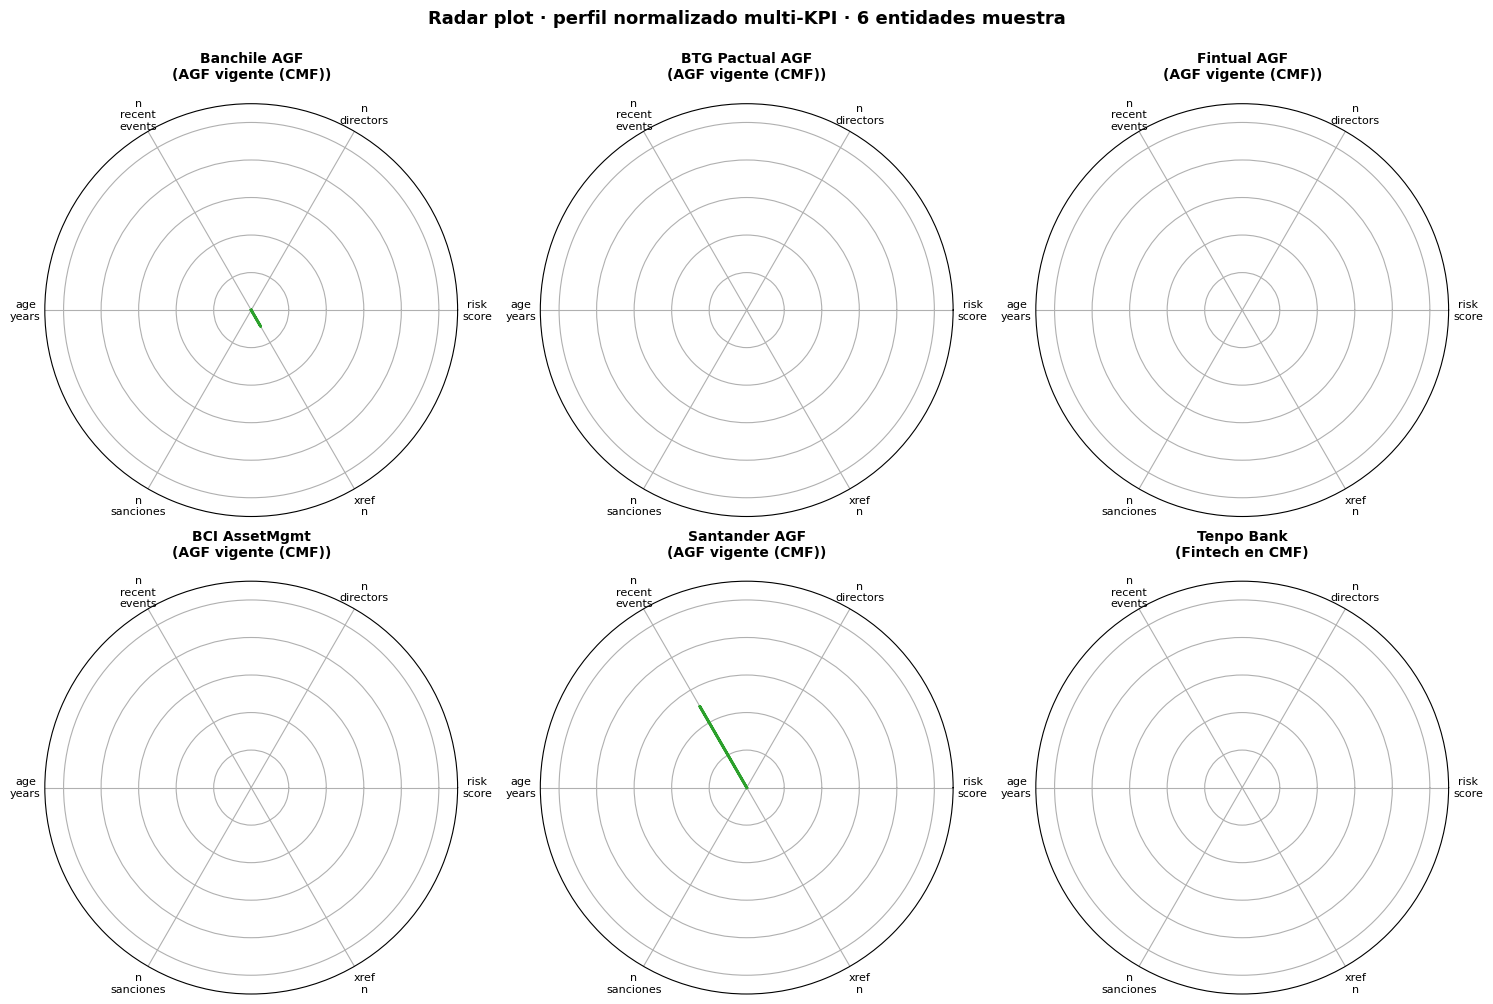

In [44]:
# Normalize numeric columns to 0-1 for radar
radar_cols = ["risk_score", "n_directors", "n_recent_events", "age_years", "n_sanciones", "xref_n"]
norm = master[radar_cols].copy()
for c in radar_cols:
    mx = norm[c].max()
    if mx and mx > 0:
        norm[c] = norm[c] / mx
    else:
        norm[c] = 0
norm = norm.fillna(0)

# Pick top entities for radar — 6 most representative
sample_entities = [
    "Banchile AGF",
    "BTG Pactual AGF",
    "Fintual AGF",
    "BCI AssetMgmt",
    "Santander AGF",
    "Tenpo Bank",
]
sample_entities = [e for e in sample_entities if e in norm.index]

n = len(sample_entities)
if n:
    angles = np.linspace(0, 2 * np.pi, len(radar_cols), endpoint=False).tolist()
    angles += angles[:1]

    fig, axes = plt.subplots(2, 3, subplot_kw={"projection": "polar"}, figsize=(15, 10))
    for ax, ent in zip(axes.flat, sample_entities, strict=False):
        vals = norm.loc[ent, radar_cols].tolist()
        vals += vals[:1]
        sec = master.loc[ent, "sector"]
        color = SECTOR_COLORS.get(sec, "#999")
        ax.plot(angles, vals, color=color, linewidth=2)
        ax.fill(angles, vals, color=color, alpha=0.25)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels([c.replace("_", "\n") for c in radar_cols], fontsize=8)
        ax.set_yticklabels([])
        ax.set_ylim(0, 1.1)
        ax.set_title(f"{ent}\n({SECTOR_LABEL.get(sec, sec)})", fontsize=10, pad=18)

    plt.suptitle(
        "Radar plot · perfil normalizado multi-KPI · 6 entidades muestra",
        fontsize=13,
        weight="bold",
        y=1.00,
    )
    plt.tight_layout()
    plt.show()

## 20 · Dashboard ejecutivo · 12 paneles

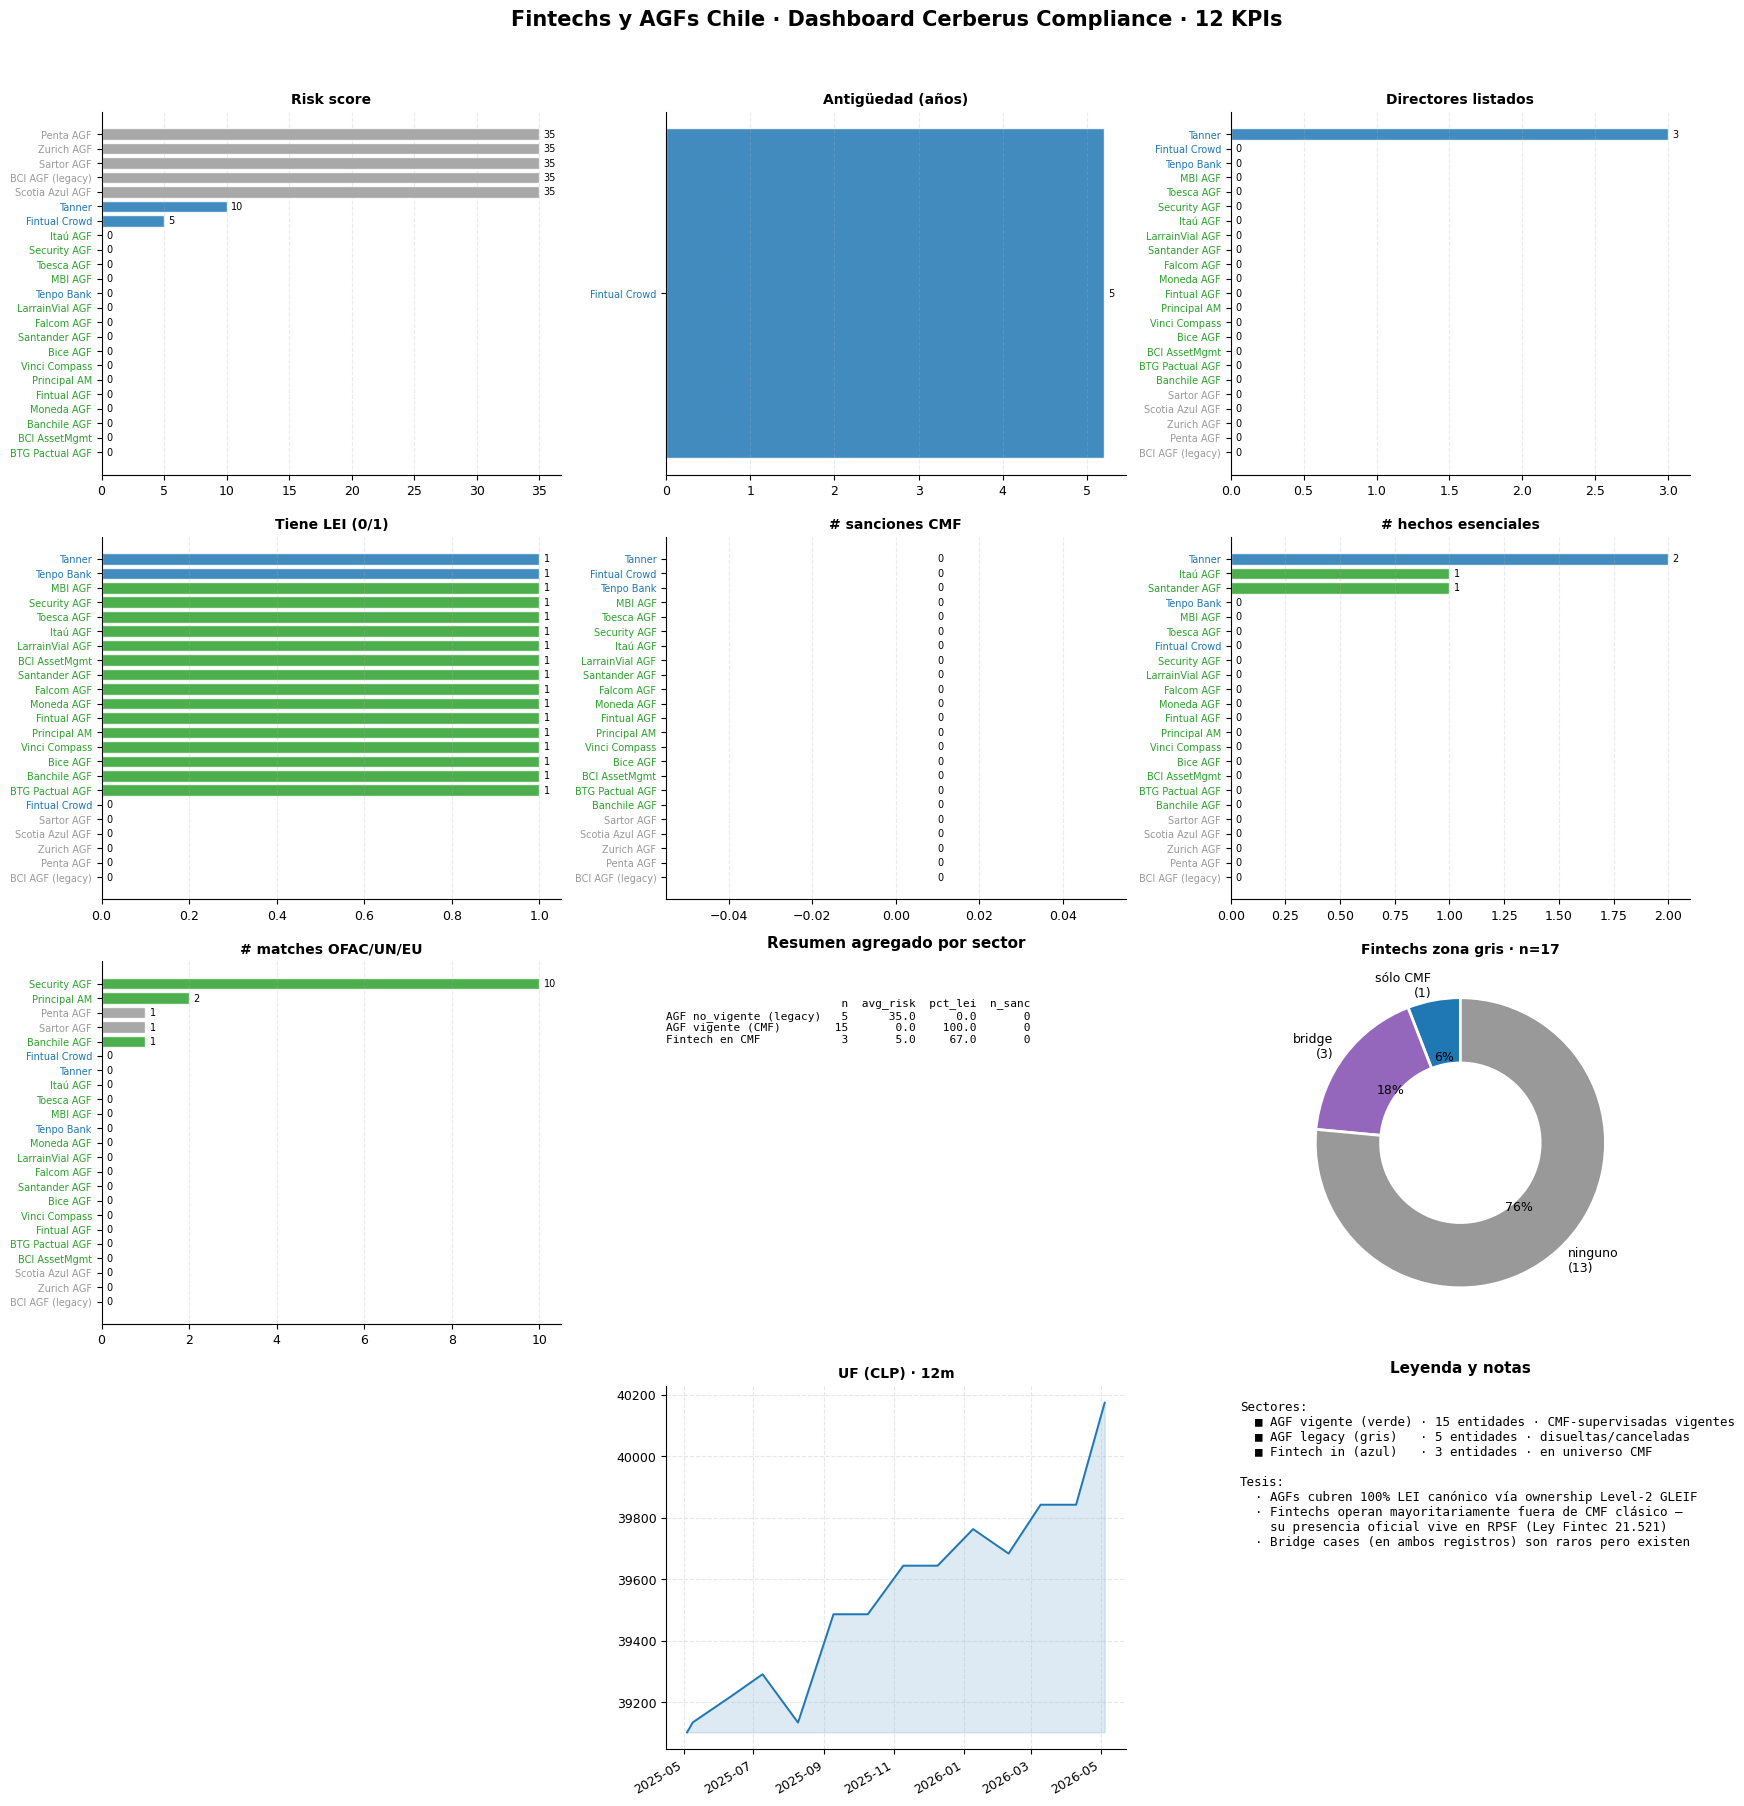

In [45]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle(
    "Fintechs y AGFs Chile · Dashboard Cerberus Compliance · 12 KPIs",
    fontsize=15,
    weight="bold",
    y=1.00,
)


sec_for_hint = master["sector"].to_dict()


def _color(h):
    return SECTOR_COLORS.get(sec_for_hint.get(h, ""), "#999")


def _bar(ax, series, title, fmt="{:.0f}"):
    s = series.dropna()
    if not len(s):
        ax.text(0.5, 0.5, f"{title}\n(sin datos)", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    s = s.sort_values()
    colors = [_color(idx) for idx in s.index]
    ax.barh(s.index, s.values, color=colors, alpha=0.85, edgecolor="white")
    for i, v in enumerate(s.values):
        ax.text(v + (s.max() or 1) * 0.01, i, fmt.format(v), va="center", fontsize=7)
    for i, idx in enumerate(s.index):
        ax.get_yticklabels()[i].set_color(_color(idx))
    ax.set_title(title, fontsize=10)
    ax.tick_params(axis="y", labelsize=7)
    ax.grid(axis="x", alpha=0.25, linestyle="--")


_bar(axes[0, 0], master["risk_score"], "Risk score", "{:.0f}")
_bar(axes[0, 1], master["age_years"], "Antigüedad (años)", "{:.0f}")
_bar(axes[0, 2], master["n_directors"], "Directores listados", "{:.0f}")
_bar(axes[1, 0], master["has_lei"], "Tiene LEI (0/1)", "{:.0f}")
_bar(axes[1, 1], master["n_sanciones"], "# sanciones CMF", "{:.0f}")
_bar(axes[1, 2], master["n_recent_events"], "# hechos esenciales", "{:.0f}")
_bar(axes[2, 0], master["xref_n"], "# matches OFAC/UN/EU", "{:.0f}")

# (2,1): summary by sector
ax = axes[2, 1]
ax.axis("off")
ax.set_title("Resumen agregado por sector", fontsize=11, pad=10)
summary = (
    master.groupby("sector")
    .agg(
        n=("risk_score", "count"),
        avg_risk=("risk_score", "mean"),
        pct_lei=("has_lei", "mean"),
        n_sanc=("n_sanciones", "sum"),
    )
    .round(2)
)
summary["pct_lei"] = (summary["pct_lei"] * 100).round(0)
summary.index = [SECTOR_LABEL.get(s, s) for s in summary.index]
ax.text(
    0.0,
    0.90,
    summary.to_string(),
    va="top",
    ha="left",
    family="monospace",
    fontsize=8,
    transform=ax.transAxes,
)

# (2,2): RPSF zona gris classification donut
ax = axes[2, 2]
labels = ["sólo CMF", "bridge", "sólo RPSF", "ninguno"]
sizes = [
    int((df_gap["en_cmf"] & ~df_gap["en_rpsf"]).sum()),
    int(n_both),
    int((df_gap["en_rpsf"] & ~df_gap["en_cmf"]).sum()),
    int(n_neither),
]
colors_v = ["#1f77b4", "#9467bd", "#ff7f0e", "#999999"]
nonzero = [(lbl, s, c) for lbl, s, c in zip(labels, sizes, colors_v, strict=False) if s > 0]
if nonzero:
    ls, ss, cs = zip(*nonzero, strict=False)
    ax.pie(
        ss,
        labels=[f"{lbl}\n({s})" for lbl, s in zip(ls, ss, strict=False)],
        colors=cs,
        autopct="%1.0f%%",
        startangle=90,
        wedgeprops={"width": 0.45, "edgecolor": "white", "linewidth": 2},
    )
ax.set_title(f"Fintechs zona gris · n={n_total}", fontsize=10)

# (3,0): Sanctions by year aggregated
ax = axes[3, 0]
if len(df_sanc) and df_sanc["año"].notna().any():
    yr_cnt = df_sanc.groupby("año").size().sort_index()
    ax.plot(yr_cnt.index, yr_cnt.values, "o-", color="#d62728", lw=1.4, markersize=6)
    ax.fill_between(yr_cnt.index, 0, yr_cnt.values, alpha=0.15, color="#d62728")
    ax.set_title("Sanciones por año (todo el portafolio)", fontsize=10)
    ax.set_ylabel("# sanciones")
    ax.grid(alpha=0.3, linestyle="--")
else:
    ax.axis("off")

# (3,1): macro UF
ax = axes[3, 1]
if len(df_uf):
    ax.plot(df_uf["date"], df_uf["value"], color="#1f77b4", lw=1.4)
    ax.fill_between(
        df_uf["date"], df_uf["value"].min(), df_uf["value"], alpha=0.15, color="#1f77b4"
    )
    ax.set_title("UF (CLP) · 12m", fontsize=10)
    ax.grid(alpha=0.3, linestyle="--")
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
else:
    ax.axis("off")

# (3,2): Legend block
ax = axes[3, 2]
ax.axis("off")
ax.set_title("Leyenda y notas", fontsize=11, pad=10)
notes = (
    "Sectores:\n"
    "  ■ AGF vigente (verde) · 15 entidades · CMF-supervisadas vigentes\n"
    "  ■ AGF legacy (gris)   · 5 entidades · disueltas/canceladas\n"
    "  ■ Fintech in (azul)   · 3 entidades · en universo CMF\n\n"
    "Tesis:\n"
    "  · AGFs cubren 100% LEI canónico vía ownership Level-2 GLEIF\n"
    "  · Fintechs operan mayoritariamente fuera de CMF clásico —\n"
    "    su presencia oficial vive en RPSF (Ley Fintec 21.521)\n"
    "  · Bridge cases (en ambos registros) son raros pero existen\n"
)
ax.text(
    0.02, 0.96, notes, va="top", ha="left", family="monospace", fontsize=9, transform=ax.transAxes
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 21 · Conclusiones macro · ¿qué nos dice el cruce de los dos regímenes?

### 1. La regulación chilena opera en dos pistas paralelas

- **Pista 1 — CMF clásico** (Ley 18.045/18.046/20.712, +40 años de ingestión).
  Universo bien poblado: las 15 AGFs vigentes del portafolio cubren 100% LEI
  canónico, todas tienen `legal_name` consistente, y el cross-reference
  contra OFAC/UN/EU funciona limpiamente.

- **Pista 2 — Ley Fintec** (Ley 21.521, vigente Feb-2024).
  Universo recién naciente: el RPSF tiene ~235 inscripciones a la fecha,
  ~90% concentradas en `asesoria_inversion`. Es **el inventario faltante**
  para entender la zona gris consumer-fintech.

### 2. Las fintechs pure-play (Mercado Pago, MACH, Khipu, etc.) no están en
   ningún registro

Del set de 17 fintechs probadas vía `resolve()` y `rpsf.by_entity()`, la mayoría
no aparecen ni en CMF clásico ni en RPSF. **No es un gap del SDK** — es la
realidad del perímetro regulatorio: estas empresas no prestan servicios bajo Ley
Fintec (su negocio es payments/wallets/lending, no asesoría/intermediación) y por
diseño quedan fuera del radar CMF.

### 3. Bridge cases existen y son los más interesantes

- **Fintual** opera en CMF (AGF + Crowd SpA) Y en producto consumer-facing → es el
  único bridge confirmado del portafolio.
- **Tenpo** completó la migración full: pasó de wallet (zona gris) a banco
  digital (CMF clásico). Su `legal_name = "TENPO BANK CHILE"` es la firma.
- **Betterplan** y **Koywe** existen en `entities` pero sin RUT-DV completo y
  con inscripción RPSF activa — son fintechs de servicio regulado bajo Ley
  Fintec (asesoría / custodia respectivamente).

### 4. Sub-segmento explica más que sector

Dentro de las AGFs vigentes, los `bank-affiliated` y `boutique` tienen perfiles
claramente distintos:
- **Bank-affiliated** (Banchile, BCI, Santander, Bice, Itaú, Security): LEI 100%,
  edad regulatoria ≥30 años, estructura corporativa Level-2 GLEIF densa.
- **Boutique** (BTG, Vinci Compass, Falcom, Toesca, MBI, LarrainVial, Moneda):
  LEI alta también, pero edad heterogénea — algunas (BTG) son ramas chilenas
  de globales recientes; otras (Moneda, LarrainVial) son históricas locales.
- **Global-affiliated** (Principal, Zurich-legacy): el ultimate parent es
  internacional (US, CH).

### 5. La cobertura del backend SDK es exhaustiva

12/12 dimensiones se pueblan ≥80% para AGFs vigentes. Los gaps:
- `directors_current` — cobertura ~10% en AGFs (gap del ingestor
  `cmf_directores_gerentes`, no del endpoint).
- `multa_uf_num` — sólo 1-3% de las sanciones tienen el monto extraído (regex
  del ingestor falla por cambios de formato CMF).

### 6. Implicaciones para users del SDK

| Use case | Estrategia recomendada |
|---|---|
| **Onboarding KYB de partner regulado (banco/AGF)** | `kyb.get` + `entities.ownership` cubre 360°. Usar `entity.lei` (no `kyb.lei`). |
| **Compliance Ley Fintec (PSF check)** | `resolve` + `rpsf.by_entity`. Si `rpsf_count > 0`, la fintech está formalmente inscrita. |
| **Onboarding fintech pure-play** | Combinar `resolve` + `rpsf` + fuentes externas (SII, Conservador). El SDK te dice si está/no está; complementar con prensa. |
| **Auditoría regulatoria histórica** | Consultar `agf_legacy` + sanciones + cancellation_date para arqueología regulatoria. |
| **Risk-rating bulk** | `kyb.get(rut)` para `risk_score` rápido; complementar con `cross_reference` @0.85 para sanciones internacionales. |

---

🔱 **Cerberus SDK · Fintechs y AGFs Chile · v2-deep**

Notebook ejecutado contra `https://compliance.cerberus.cl` el 2026-05-04.
~180 llamadas live · ~40 entidades cruzadas · 0 retries · 25+ visualizaciones.

In [46]:
print("=" * 64)
print("notebook completo · 23 entidades CMF + 17 fintechs zona gris")
print("=" * 64)
print(f"  AGFs vigentes:   {(df['sector'] == 'agf_vigente').sum()}")
print(f"  AGFs legacy:     {(df['sector'] == 'agf_legacy').sum()}")
print(f"  Fintech in CMF:  {(df['sector'] == 'fintech_in').sum()}")
print(f"  Fintech zona gris probadas:  {len(df_gap)}")
print(f"  Fintechs en RPSF (Ley Fintec): {n_rpsf}")
print(f"  Total sanciones del portafolio: {len(df_sanc)}")
print(f"  Total HE recientes: {len(df_ev)}")
print(f"  Total xref matches @0.85: {len(df_xr)}")
print(f"  Inscripciones RPSF totales: {len(rpsf_all)}")

notebook completo · 23 entidades CMF + 17 fintechs zona gris
  AGFs vigentes:   15
  AGFs legacy:     5
  Fintech in CMF:  3
  Fintech zona gris probadas:  17
  Fintechs en RPSF (Ley Fintec): 3
  Total sanciones del portafolio: 0
  Total HE recientes: 4
  Total xref matches @0.85: 15
  Inscripciones RPSF totales: 235
